# CS4168 Data Mining Group Project 
# Spotify Tracks 2026
Contribution distribution: 25% each

Joe Considine: Contributed mainly to sections 4 and 5 of the code based on the labs.

Caylum Hurley: Contributed mainly to sections 1, 2 and 3 of the code based on the labs.

Darragh Quinn: Contributed mainly to section 2 and created the project demonstration video.

Ugochukwu Egbokwu: Contributed mainly to sections 3 and 4 of the code based on the labs.


## 1. Setup and Load Data

In [1]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn import manifold, set_config

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor

from sklearn.preprocessing import (
    StandardScaler, RobustScaler,MinMaxScaler,
    OneHotEncoder,FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.feature_selection import RFE
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, KFold,
    cross_validate, cross_val_predict
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    auc, accuracy_score, precision_score, recall_score,
    f1_score, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

import pickle

RANDOM_STATE = 42

df = pd.read_csv("tracks2026.csv")
df.head()

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


## 2. Exploratory Data Analysis (EDA)

### 2.1 Quick Data Exploration

In [2]:
# fist 5
df.head(5)

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


In [3]:
# last 5
df.tail(5)

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop
1999,46qnV2b4tq0QqJwIoZwMyJ,25.0,244026,False,0.746,0.570,7,-10.599,1,0.0389,0.6660,0.000005,0.3200,0.657,109.929,4,synth-pop


In [4]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,1960.000000,2000.000000,1960.000000,1960.000000,2000.000000,1961.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1960.000000,2000.000000
mean,39.805102,217806.433000,0.635897,0.632489,5.295500,400.575884,0.637500,0.078466,0.297378,0.030269,0.180715,0.539963,120.040092,3.912000
std,29.245904,56804.759189,0.138298,0.189087,3.567148,18065.717039,0.480842,0.076223,0.279793,0.119946,0.149938,0.236062,28.520528,0.425848
min,0.000000,60000.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000
25%,1.750000,181210.000000,0.548000,0.507750,2.000000,-8.988000,0.000000,0.034475,0.052475,0.000000,0.093775,0.353000,96.956000,4.000000
50%,45.000000,211346.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047500,0.195500,0.000007,0.121000,0.536000,118.711500,4.000000
75%,65.000000,246069.750000,0.738000,0.780000,8.000000,-5.390000,1.000000,0.084950,0.490250,0.000638,0.221250,0.730000,139.746250,4.000000
max,100.000000,561133.000000,0.953000,0.996000,11.000000,800000.000000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000


In [5]:
print("Shape:", df.shape)
print("\nMissing vals:")

display(df.isna().sum().sort_values(ascending=False))

print("\nCount of nonnull per column:")

display(df.count())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate track_id values:", df["track_id"].duplicated().sum())

Shape: (2000, 17)

Missing vals:


popularity          40
energy              40
danceability        40
tempo               40
loudness            39
track_id             0
explicit             0
key                  0
duration_ms          0
mode                 0
speechiness          0
instrumentalness     0
acousticness         0
liveness             0
valence              0
time_signature       0
track_genre          0
dtype: int64


Count of nonnull per column:


track_id            2000
popularity          1960
duration_ms         2000
explicit            2000
danceability        1960
energy              1960
key                 2000
loudness            1961
mode                2000
speechiness         2000
acousticness        2000
instrumentalness    2000
liveness            2000
valence             2000
tempo               1960
time_signature      2000
track_genre         2000
dtype: int64


Duplicate rows: 6
Duplicate track_id values: 32


### 2.2 Quick Examination of Categorical Attributes

In [6]:
frequency_genre = df["track_genre"].value_counts()
print("Genere frequency table:")
print(frequency_genre)
print("\nTotal tracsk with genre:", df["track_genre"].count())

Genere frequency table:
track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300
Name: count, dtype: int64

Total tracsk with genre: 2000


In [7]:
frequency_explicit = df["explicit"].value_counts(ascending=True)

print("Frequency Table for Explicit:")
print(frequency_explicit)
print("\nTotal tracks flagged explicit:", df["explicit"].count())

Frequency Table for Explicit:
explicit
True      223
False    1777
Name: count, dtype: int64

Total tracks flagged explicit: 2000


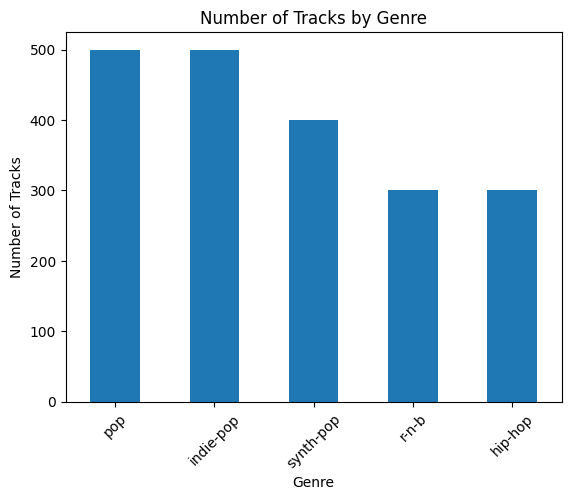

In [8]:
frequency_genre.plot(kind="bar")

plt.xlabel("Genre")
plt.ylabel("Number of Tracks")

plt.title("Number of Tracks by Genre")
plt.xticks(rotation=45)

plt.show()

### 2.3 Distribution Analysis for Numerical Attributes

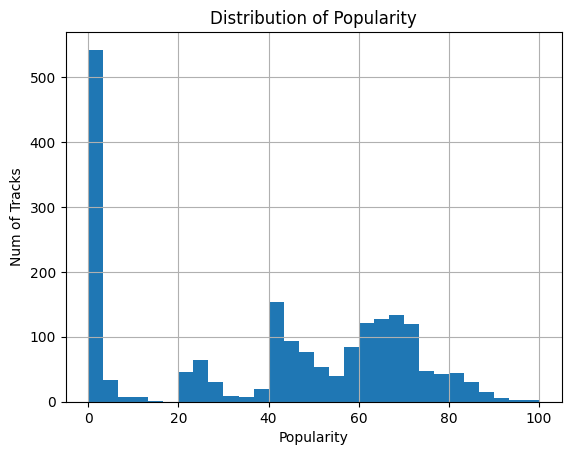

In [9]:
df["popularity"].hist(bins=30)

plt.xlabel("Popularity")
plt.ylabel("Num of Tracks")
plt.title("Distribution of Popularity")
plt.show()

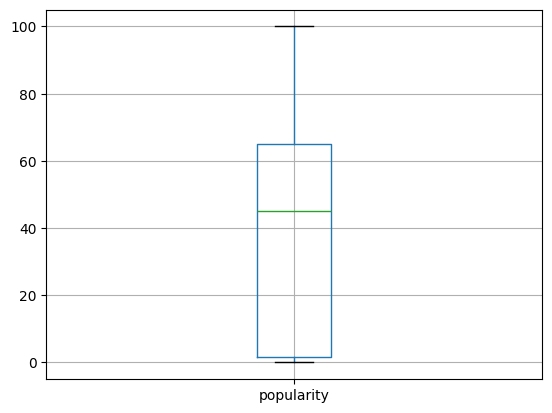

In [10]:
df.boxplot(column="popularity")
plt.show()

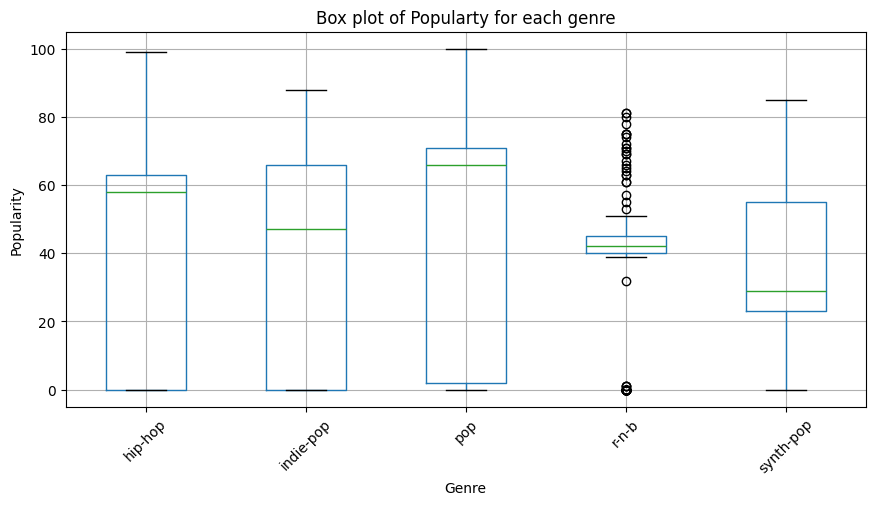

In [11]:
df.boxplot(column="popularity", by="track_genre", rot=45, figsize=(10, 5))

plt.title("Box plot of Popularty for each genre")
plt.suptitle("")

plt.xlabel("Genre")
plt.ylabel("Popularity")

plt.show()

,danceability,energy,speechiness,acousticness
count,1960.000000,1960.000000,2000.000000,2000.000000
mean,0.635897,0.632489,0.078466,0.297378
std,0.138298,0.189087,0.076223,0.279793
min,0.185000,0.090900,0.022100,0.000007
25%,0.548000,0.507750,0.034475,0.052475
50%,0.646000,0.644000,0.047500,0.195500
75%,0.738000,0.780000,0.084950,0.490250
max,0.953000,0.996000,0.515000,0.990000


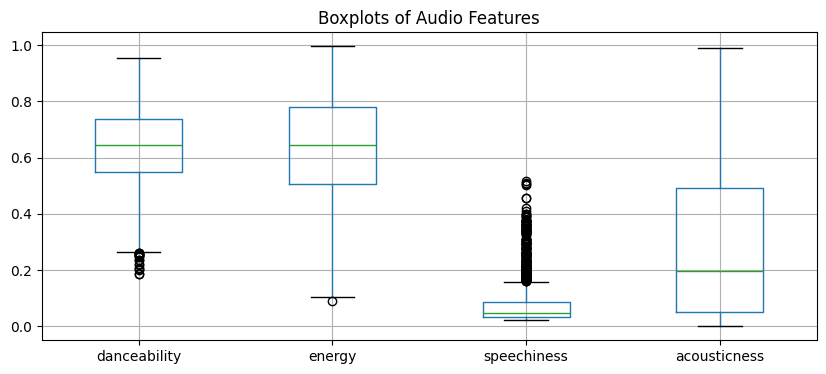

In [12]:
group1_cols = ["danceability", "energy", "speechiness", "acousticness"]
display(df[group1_cols].describe())
df[group1_cols].boxplot(figsize=(10, 4))

plt.title("Boxplots of Audio Features")
plt.show()

,instrumentalness,liveness,valence,loudness
count,2000.000000,2000.000000,2000.000000,1961.000000
mean,0.030269,0.180715,0.539963,400.575884
std,0.119946,0.149938,0.236062,18065.717039
min,0.000000,0.009860,0.035900,-21.089000
25%,0.000000,0.093775,0.353000,-8.988000
50%,0.000007,0.121000,0.536000,-6.924000
75%,0.000638,0.221250,0.730000,-5.390000
max,0.962000,0.986000,0.990000,800000.000000


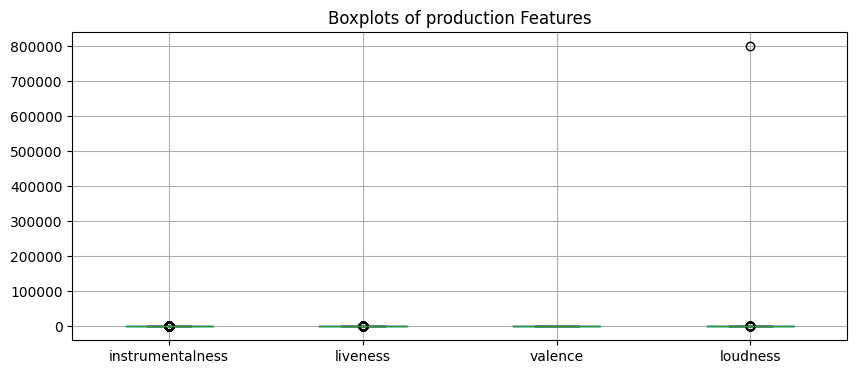

In [13]:
group2_cols = ["instrumentalness", "liveness", "valence", "loudness"]

display(df[group2_cols].describe())
df[group2_cols].boxplot(figsize=(10, 4))
plt.title("Boxplots of production Features")
plt.show()

,tempo,duration_ms,key,mode,time_signature
count,1960.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,120.040092,217806.433000,5.295500,0.637500,3.912000
std,28.520528,56804.759189,3.567148,0.480842,0.425848
min,51.037000,60000.000000,0.000000,0.000000,1.000000
25%,96.956000,181210.000000,2.000000,0.000000,4.000000
50%,118.711500,211346.000000,5.000000,1.000000,4.000000
75%,139.746250,246069.750000,8.000000,1.000000,4.000000
max,205.895000,561133.000000,11.000000,1.000000,5.000000


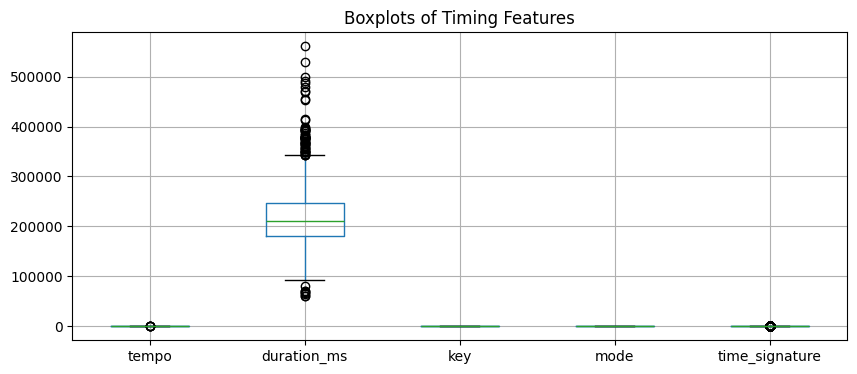

In [14]:
group3_cols = ["tempo", "duration_ms", "key", "mode", "time_signature"]

display(df[group3_cols].describe())
df[group3_cols].boxplot(figsize=(10, 4))

plt.title("Boxplots of Timing Features")
plt.show()

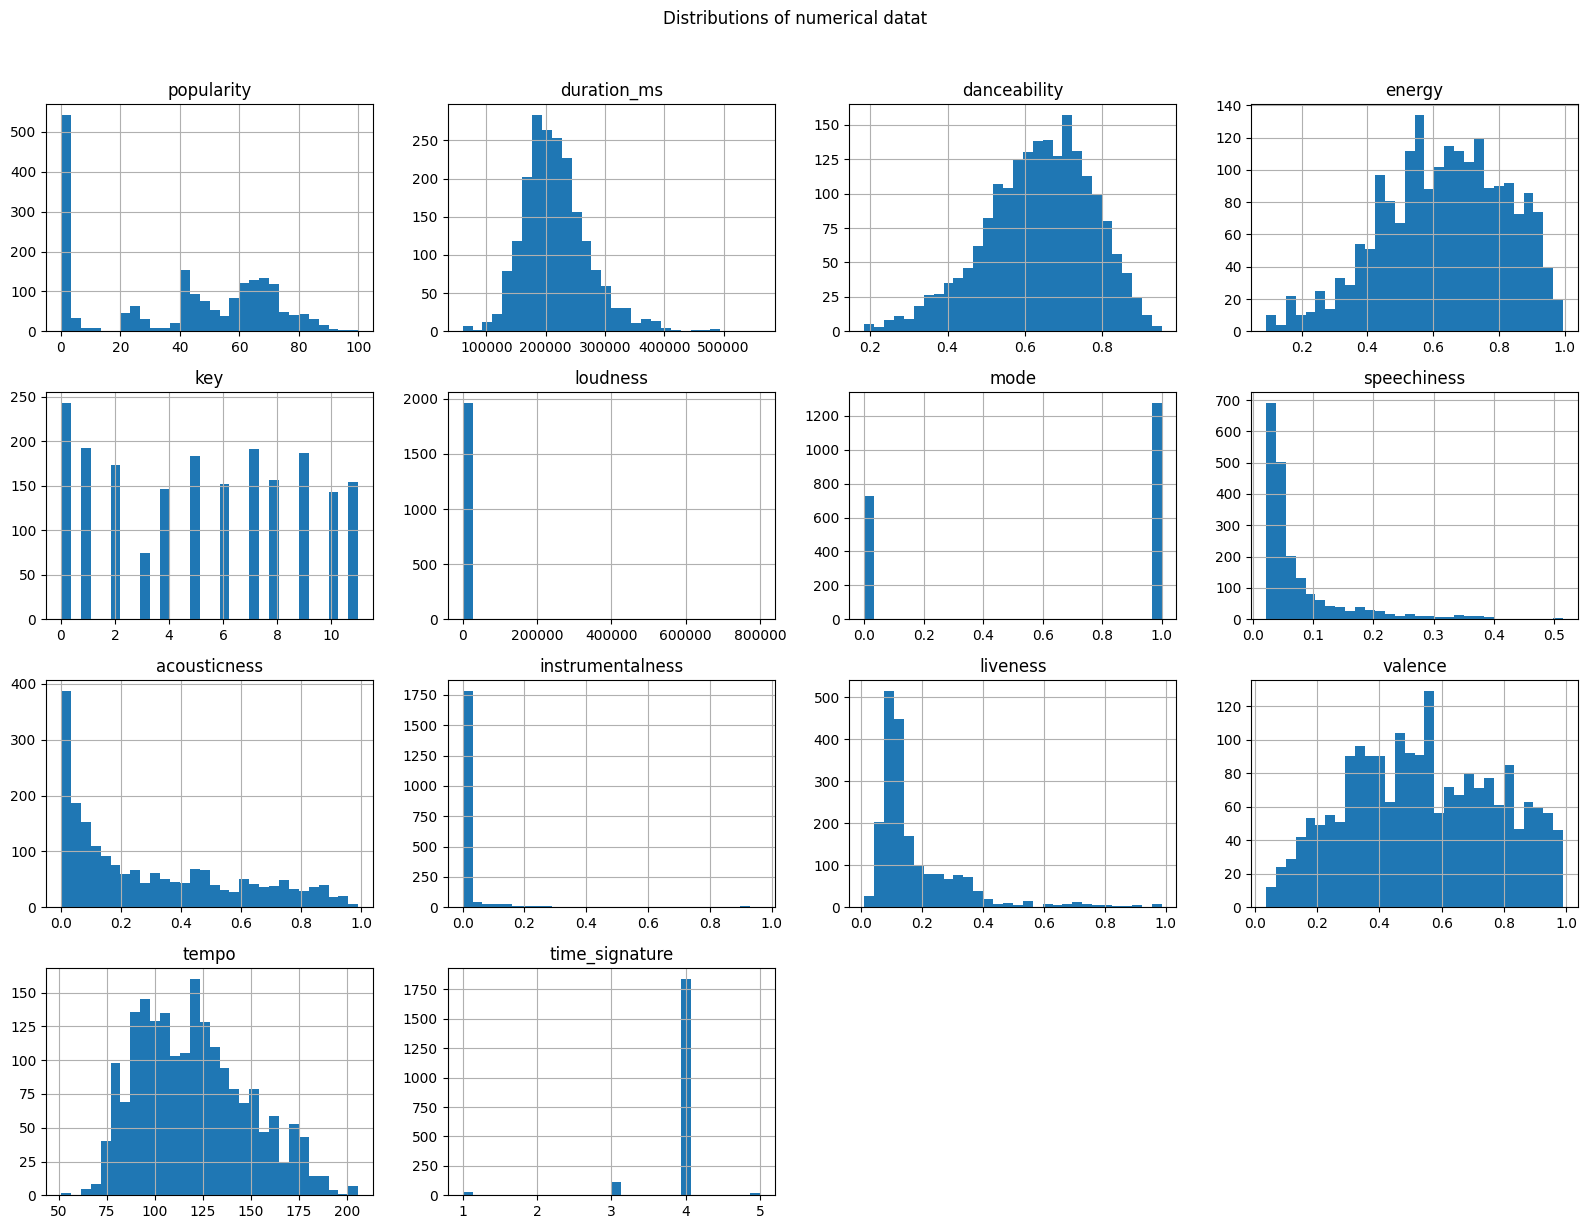

In [15]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

df[numeric_cols].hist(bins=30, figsize=(16, 12))

plt.suptitle("Distributions of numerical datat", y=1.02)
plt.tight_layout()
plt.show()

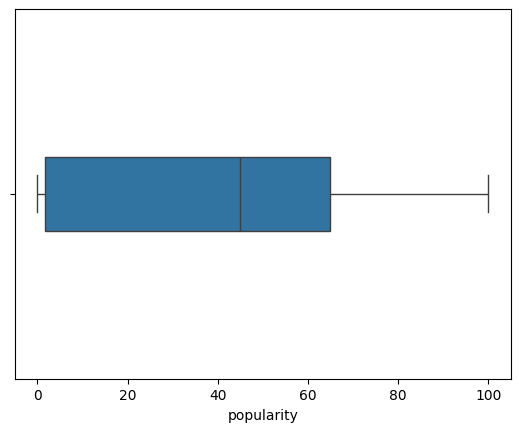

In [16]:
sns.boxplot(x=df["popularity"], orient="v", width=0.2)
plt.show()

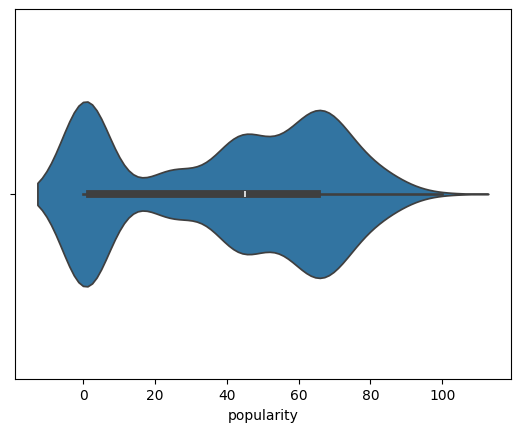

In [17]:
sns.violinplot(x=df["popularity"], orient="v", width=0.5)

plt.show()

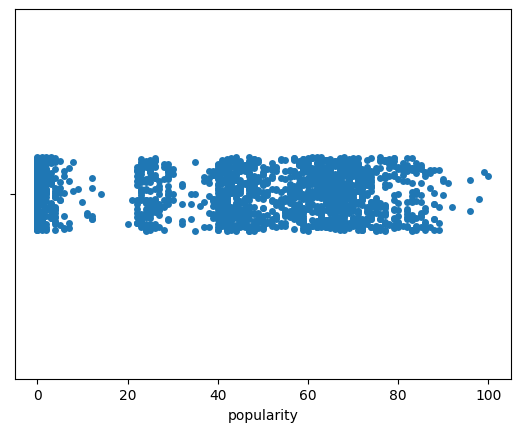

In [18]:
sns.stripplot(x=df["popularity"], jitter=True, orient="v")
plt.show()

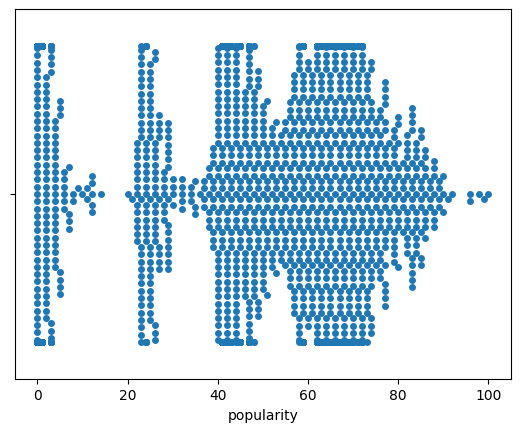

In [19]:
sns.swarmplot(x=df["popularity"], orient="v")
plt.show()

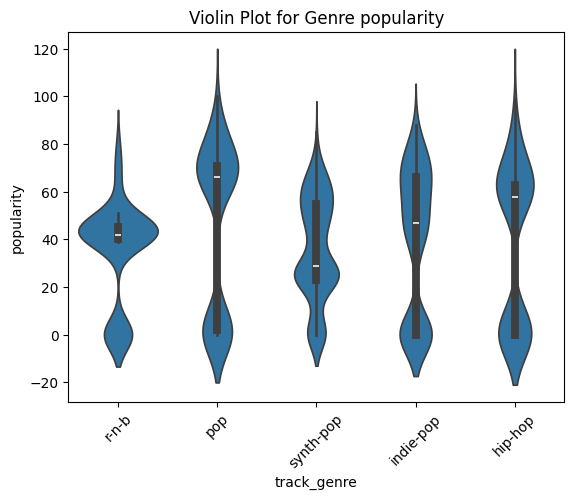

In [20]:
sns.violinplot(data=df, x="track_genre", y="popularity")

plt.title("Violin Plot for Genre popularity")
plt.xticks(rotation=45)
plt.show()

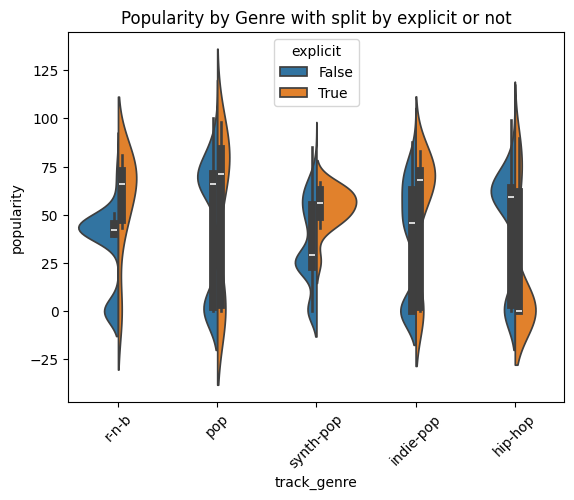

In [21]:
sns.violinplot(data=df, x="track_genre", y="popularity",
               hue="explicit", split=True)

plt.title("Popularity by Genre with split by explicit or not")
plt.xticks(rotation=45)

plt.show()

### 2.4 Correlation Heatmap

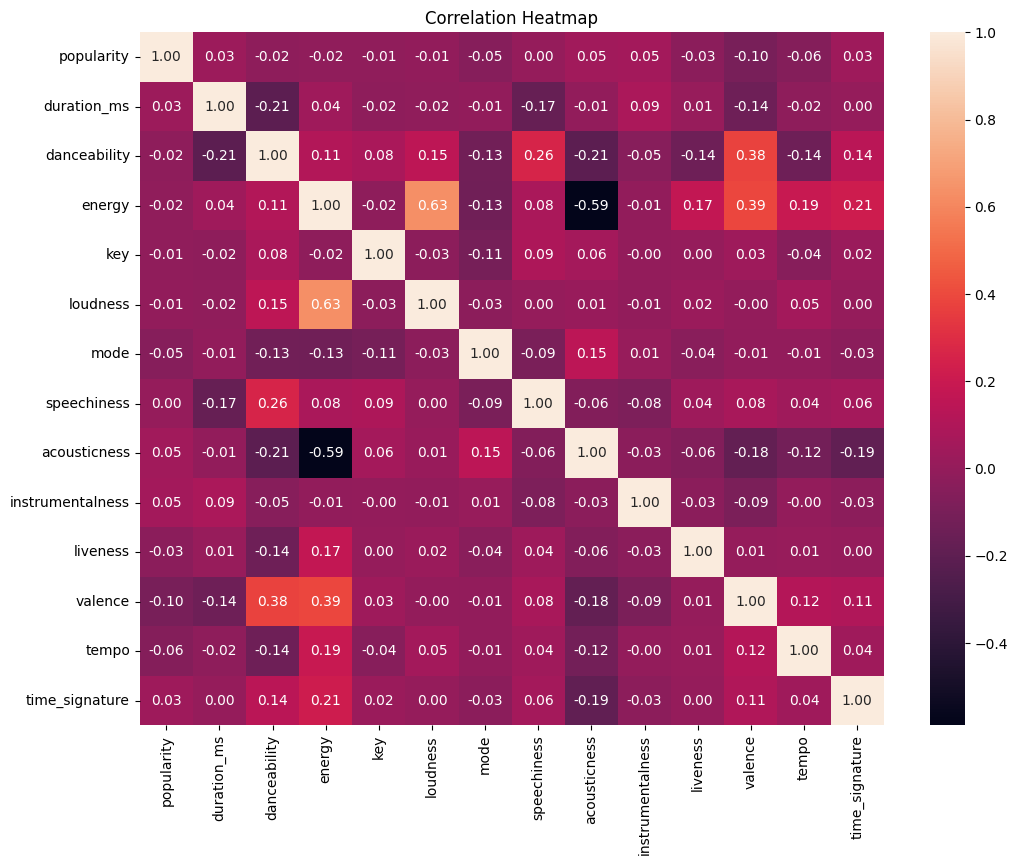


Correlation with popularity:


popularity          1.000000
instrumentalness    0.052461
acousticness        0.049778
time_signature      0.032678
duration_ms         0.026282
speechiness         0.004288
loudness           -0.010803
key                -0.013315
energy             -0.017372
danceability       -0.023186
liveness           -0.033469
mode               -0.050896
tempo              -0.056942
valence            -0.100355
Name: popularity, dtype: float64

In [22]:
plt.figure(figsize=(12, 9))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

print("\nCorrelation with popularity:")

display(df[numeric_cols].corr()["popularity"].sort_values(ascending=False))

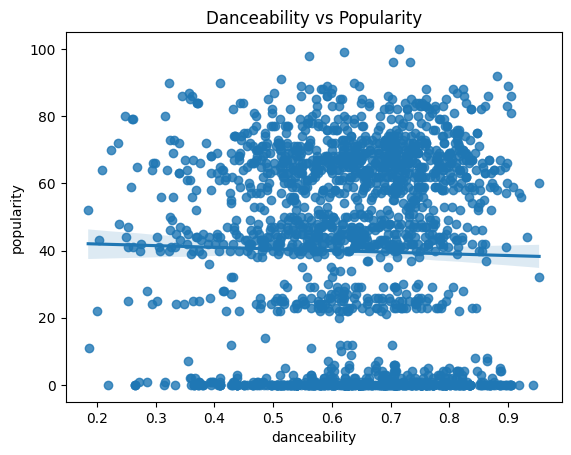

In [23]:
sns.regplot(data=df, x="danceability", y="popularity")

plt.title("Danceability vs Popularity")
plt.show()

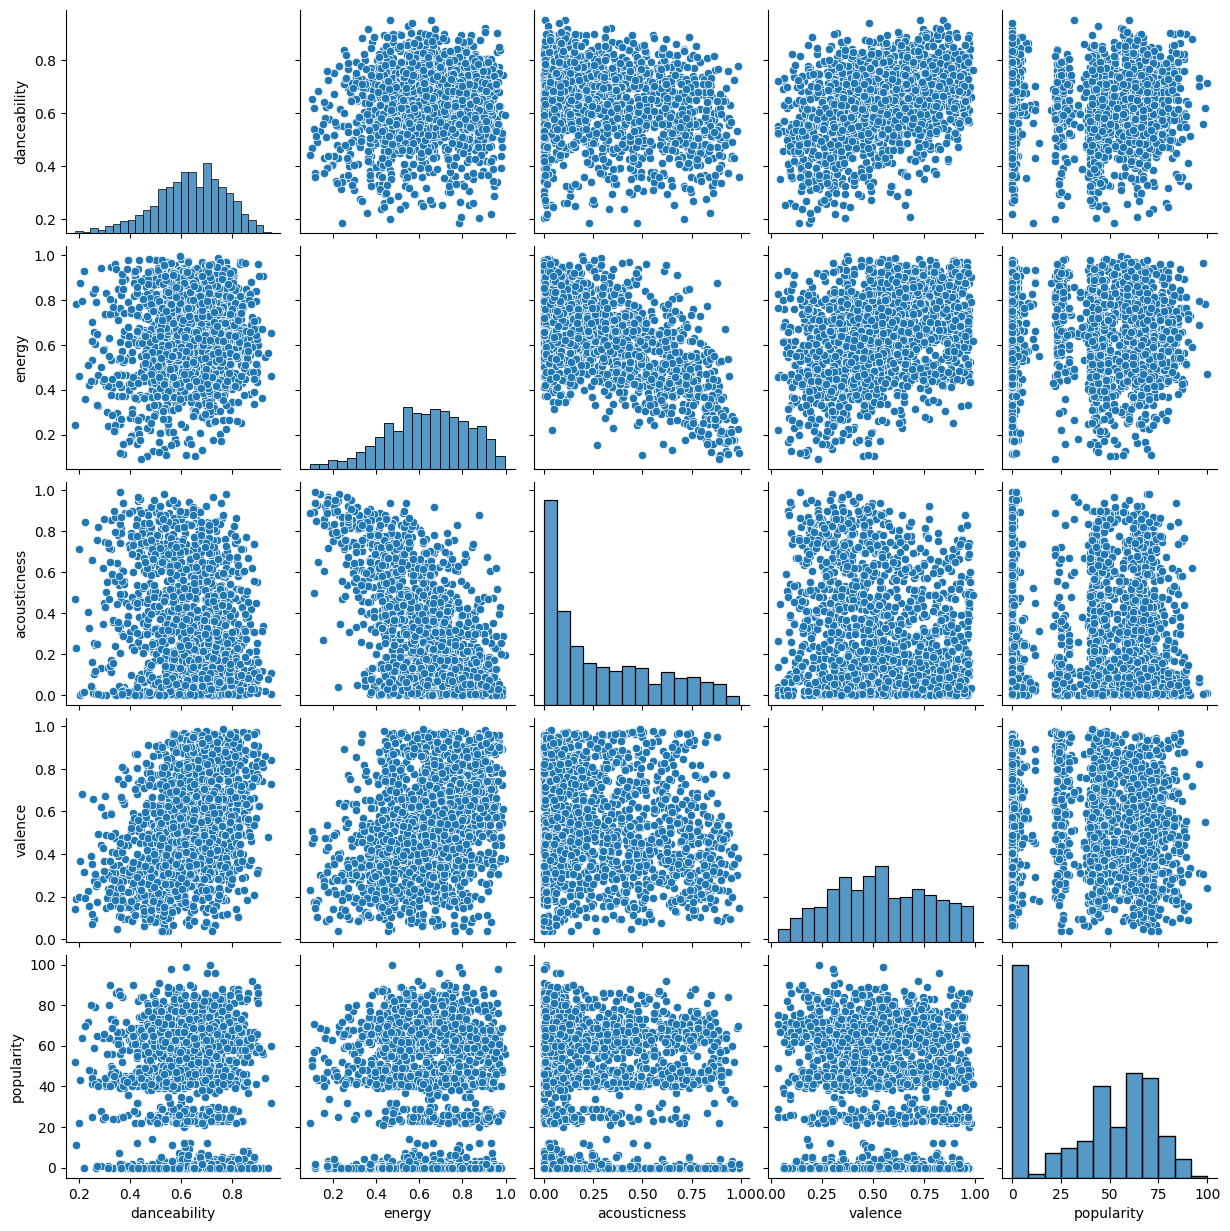

In [24]:
sns.pairplot(data=df[["danceability","energy","acousticness","valence","popularity"]].dropna())

plt.show()

### 2.5 Distribution Analysis for Categorical Attributes

          popularity
explicit            
False      39.876005
True       39.238532


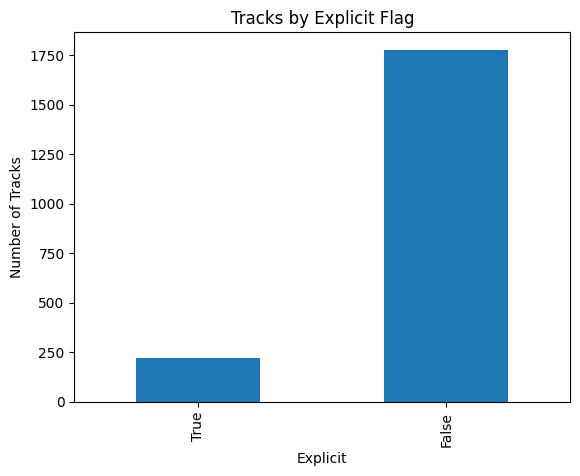

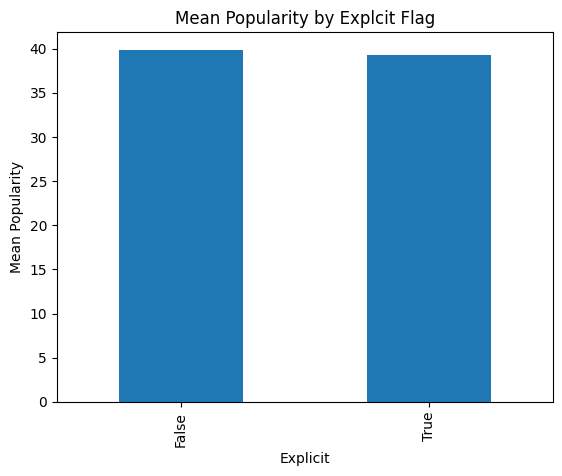

In [25]:
pivot_table_EP = df.pivot_table(
    values="popularity",
    index="explicit",
    aggfunc=lambda x: x.mean()
)
print(pivot_table_EP)

frequency_explicit.plot(kind="bar")

plt.xlabel("Explicit")
plt.ylabel("Number of Tracks")

plt.title("Tracks by Explicit Flag")

plt.show()

pivot_table_EP.plot(kind="bar")

plt.xlabel("Explicit")
plt.ylabel("Mean Popularity")

plt.title("Mean Popularity by Explcit Flag")
plt.legend().set_visible(False)

plt.show()

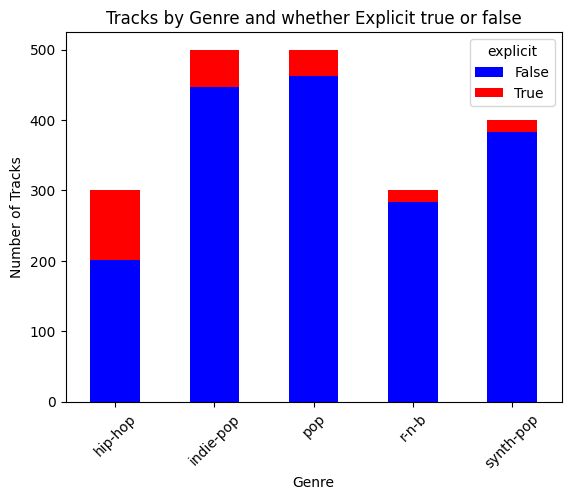

In [26]:
crosstab_GE = pd.crosstab(df["track_genre"], df["explicit"])
crosstab_GE.plot(kind="bar", stacked=True, color=["blue", "red"])

plt.ylabel("Number of Tracks")
plt.xlabel("Genre")

plt.title("Tracks by Genre and whether Explicit true or false")

plt.xticks(rotation=45)
plt.show()

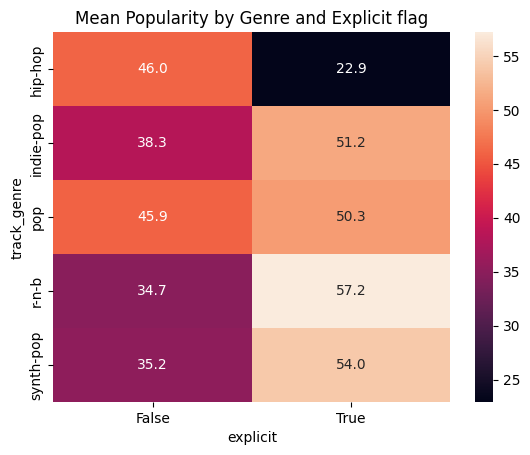

In [27]:
pivot_table_GE = df.pivot_table(
    values="popularity",
    index="track_genre",
    columns="explicit",
    aggfunc=lambda x: x.mean()
)

sns.heatmap(pivot_table_GE, annot=True, fmt=".1f")

plt.title("Mean Popularity by Genre and Explicit flag")
plt.show()

### 2.6 Data Cleaning

In [28]:
# save copy dataaset before transformation
df_original = df.copy()

df_clean = df.copy()
df_clean.drop(columns=["track_id"], inplace=True)

df_clean["explicit"] = df_clean["explicit"].astype(int)

print("loudness outlier row:")

display(df_clean[df_clean["loudness"] > 5][["loudness", "track_genre"]])
df_clean.loc[df_clean["loudness"] > 5, "loudness"] = np.nan

print("\n check for zero in key numeric columns:")

for col in ["popularity", "instrumentalness", "key", "mode"]:
    print(f"  {col}: {(df_clean[col] == 0).sum()} zeros")

print("\nMisssing values after cleaning:")

display(df_clean.isna().sum())

loudness outlier row:


,loudness,track_genre
1289,800000.0,pop



 check for zero in key numeric columns:
  popularity: 422 zeros
  instrumentalness: 818 zeros
  key: 243 zeros
  mode: 725 zeros

Misssing values after cleaning:


popularity          40
duration_ms          0
explicit             0
danceability        40
energy              40
key                  0
loudness            40
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo               40
time_signature       0
track_genre          0
dtype: int64

In [29]:
df_clean = df_clean.dropna(subset=["popularity", "danceability", "energy", "tempo"])

print(df_clean.shape)
display(df_clean.isna().sum())

(1960, 16)


popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

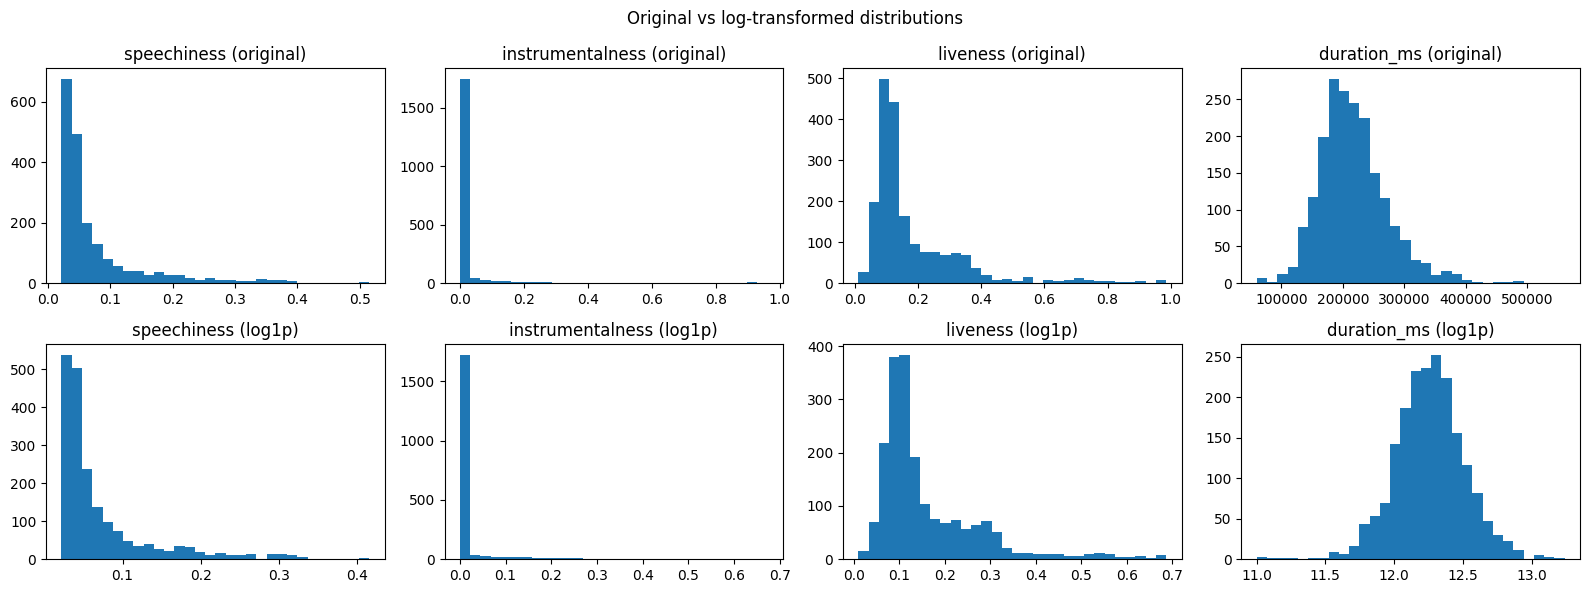

In [30]:
skewed_cols = ["speechiness", "instrumentalness", "liveness", "duration_ms"]

fig, axes = plt.subplots(2, len(skewed_cols), figsize=(16, 6))

for i, col in enumerate(skewed_cols):
    axes[0, i].hist(df_clean[col], bins=30)
    axes[0, i].set_title(f"{col} (original)")
    axes[1, i].hist(np.log1p(df_clean[col]), bins=30)
    axes[1, i].set_title(f"{col} (log1p)")

plt.suptitle("Original vs log-transformed distributions")

plt.tight_layout()

plt.show()

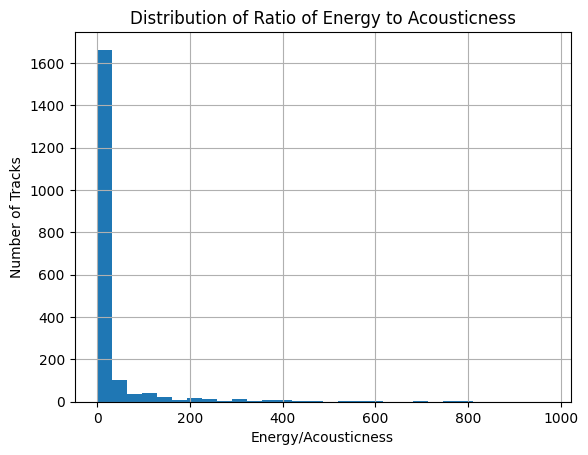

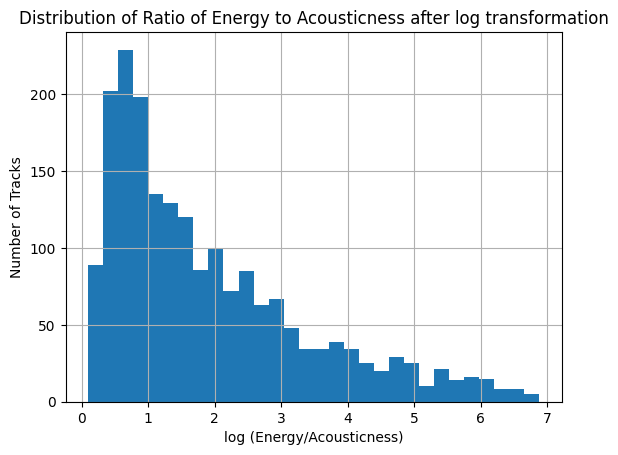

In [31]:
df_clean["energy_acoustic_ratio"] = df_clean["energy"] / (df_clean["acousticness"] + 0.001)

df_clean["energy_acoustic_ratio"].hist(bins=30)

plt.xlabel("Energy/Acousticness")
plt.ylabel("Number of Tracks")

plt.title("Distribution of Ratio of Energy to Acousticness")

plt.show()

df_clean["energy_acoustic_ratio"] = np.log1p(df_clean["energy_acoustic_ratio"])
df_clean["energy_acoustic_ratio"].hist(bins=30)

plt.xlabel("log (Energy/Acousticness)")
plt.ylabel("Number of Tracks")

plt.title("Distribution of Ratio of Energy to Acousticness after log transformation")

plt.show()

In [32]:
df_clean.to_csv("tracks2026_prepared.csv", index=False)

print("Prepared dataset saved. Shape:", df_clean.shape)
display(df_clean.head())

Prepared dataset saved. Shape: (1960, 17)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,energy_acoustic_ratio
0,44.0,203337,0,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b,0.876948
1,83.0,208786,0,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop,1.882929
2,49.0,262373,0,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop,1.178655
3,0.0,191733,0,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop,2.808360
4,41.0,283706,0,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop,1.316891


**Observations from EDA:**
There are 2,000 tracks in the dataset, featuring 5 different genres. The dataset features 500 Pop and Indie-pop songs each, 400 synth-pop tracks, as well as 300 r&b and hip-hop tacks each. This imbalance shouoldn't cause major issues but we decided it was still worth noting.

Looking at popularity,it has a bimodal distibution, with a large spike at 0 and another between 50 and 80. The spike at 0 represents more obscure tracks while 50-80 represents more mainstrream ones. This makes regression harder than classification because the model has to predict across the whole range instead of simply being able to say its above or below the median.

Instead of imputing the missing popularity values, the rows where simply removed. If a target varialbe was added to the training data, articifical signal would be added. There's an obvious data entry mistakes where a loudness value is set at 800,000 dB. This is set to NaN and handled by median imputatuoin in the pipeline.

Zeros in these columns are valid Instrumentalness of 0 means the track has vocals, key of 0 means the key of C, and mode of 0 means minor.

Speechiness, intrumentalness, livenes adn duraton_ms each have a strong right-skew. Before scaling, a log transformation was applied to reduce this skew. Key and time_signature don't have ordinal meaning and are one-hot encoded. The energy-to-acousticness ratio was made to show whether a track is produced, electronic or organic. These observations directly informed our preprocessing choices.

## 3. Clustering (Descriptive Analytics)

### 3.1 Data Preparation for Clustering

In [33]:
cluster_df = df_clean.drop(columns=["track_genre"])

log_cols      = ["speechiness", "instrumentalness", "liveness", "duration_ms"]
robust_cols   = ["loudness"]
standard_cols = ["danceability", "energy", "acousticness", "valence", "tempo",
                 "energy_acoustic_ratio", "explicit", "mode"]
ohe_cols      = ["key", "time_signature"]

print("Log-transform columns:", log_cols)
print("RobustScaler columns:", robust_cols)
print("StandardScaler columns:", standard_cols)
print("OneHotEncoder columns:", ohe_cols)

Log-transform columns: ['speechiness', 'instrumentalness', 'liveness', 'duration_ms']
RobustScaler columns: ['loudness']
StandardScaler columns: ['danceability', 'energy', 'acousticness', 'valence', 'tempo', 'energy_acoustic_ratio', 'explicit', 'mode']
OneHotEncoder columns: ['key', 'time_signature']


In [34]:
log_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scaler", MinMaxScaler())
]
)

robust_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

standard_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
]
)

cluster_preprocess = ColumnTransformer(
    transformers=[
        ("log_cols",      log_pipeline,      log_cols),
        ("robust_cols",   robust_pipeline,   robust_cols),
        ("standard_cols", standard_pipeline, standard_cols),
        ("ohe_cols",      OneHotEncoder(handle_unknown="ignore", sparse_output=False), ohe_cols)
    ]

)

set_config(display="diagram")
cluster_preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_cols', ...), ('robust_cols', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feat

In [35]:
X_cluster = cluster_preprocess.fit_transform(cluster_df)
genre_codes = pd.factorize(df_clean["track_genre"])[0]

print("Cluster matrix shape:", X_cluster.shape)

Cluster matrix shape: (1960, 29)


### 3.2 K-Means Clustering

,k,inertia,silhouette,ARI_vs_genre
0,2,15448.207819,0.180596,0.021636
1,3,13552.449005,0.203507,0.035697
2,4,12285.613744,0.157392,0.042176
3,5,11322.489079,0.161052,0.050114
4,6,10830.918317,0.151981,0.046739
5,7,10406.061135,0.141031,0.042915
6,8,10012.784417,0.128568,0.043153
7,9,9714.008729,0.131748,0.041266
8,10,9381.578590,0.131043,0.038954


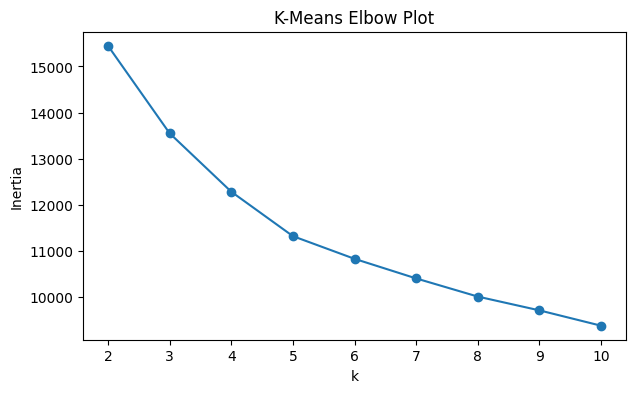

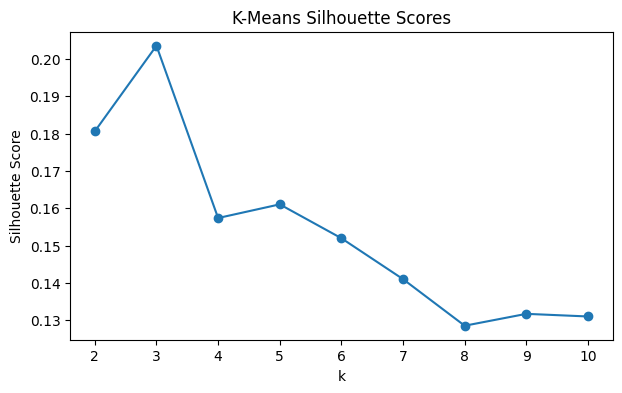

In [36]:
k_values = range(2, 11)
kmeans_results = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)

    labels = km.fit_predict(X_cluster)

    kmeans_results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_cluster, labels),
        "ARI_vs_genre": adjusted_rand_score(genre_codes, labels)
    }
    )

kmeans_results = pd.DataFrame(kmeans_results)

display(kmeans_results)

plt.figure(figsize=(7, 4))

plt.plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
plt.title("K-Means Elbow Plot")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.show()

plt.figure(figsize=(7, 4))
plt.plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o")
plt.title("K-Means Silhouette Scores")
plt.xlabel("k")
plt.ylabel("Silhouette Score")


plt.show()

In [37]:
for k in [3, 5]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    
    print(f"\nK-Means k={k}")
    print("Silhouette:", round(silhouette_score(X_cluster, labels), 3))
    print("ARI vs genre:", round(adjusted_rand_score(genre_codes, labels), 3))

    display(pd.crosstab(labels, df_clean["track_genre"], normalize="index").round(2))


K-Means k=3
Silhouette: 0.204
ARI vs genre: 0.036


track_genre,hip-hop,indie-pop,pop,r-n-b,synth-pop
row_0,,,,,
0,0.15,0.18,0.24,0.15,0.28
1,0.44,0.24,0.17,0.07,0.08
2,0.05,0.37,0.29,0.18,0.12



K-Means k=5
Silhouette: 0.161
ARI vs genre: 0.05


track_genre,hip-hop,indie-pop,pop,r-n-b,synth-pop
row_0,,,,,
0,0.05,0.41,0.28,0.15,0.11
1,0.07,0.27,0.16,0.14,0.36
2,0.45,0.24,0.17,0.07,0.08
3,0.21,0.12,0.37,0.11,0.19
4,0.11,0.21,0.20,0.23,0.25


In [38]:
colours = np.array(["orange", "blue", "lime", "khaki", "pink", "green", "purple"])

def clustering_scatterplot(points, labels, centers, title):
    n_clusters = len(np.unique(labels[labels >= 0]))

    for i in range(n_clusters):
        plt.scatter(points[labels == i, 0], points[labels == i, 1],
                    c=colours[i % colours.size], label=f"cluster {i}", s=15)
    if -1 in labels:
        plt.scatter(points[labels == -1, 0], points[labels == -1, 1],
                    c="black", label="noise", s=10, alpha=0.3)
    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], c="r", marker="*", s=500)

    plt.title(title)

    plt.legend()
    
    plt.xlabel("x")
    plt.ylabel("y")

In [39]:
chosen_k = 5 

pipe_km = Pipeline(steps=[
    ("preprocess", cluster_preprocess),
    ("kMeans", KMeans(n_clusters=chosen_k, n_init=10, max_iter=300, random_state=RANDOM_STATE))
]
)

set_config(display="diagram")
pipe_km

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('kMeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_cols', ...), ('robust_cols', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [40]:
clustering_model = pipe_km.fit(cluster_df)

preprocessed_data = clustering_model["preprocess"].transform(cluster_df)
kmeans_labels = clustering_model["kMeans"].labels_

MDS transformation complete


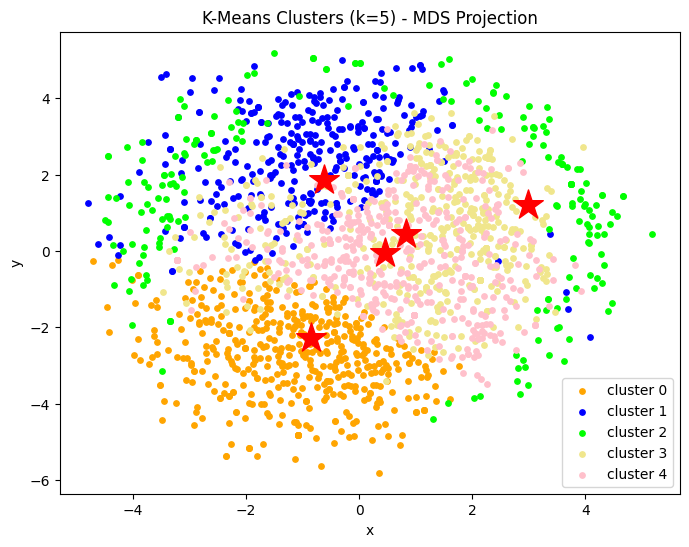

In [41]:
data_and_centers = np.r_[preprocessed_data, clustering_model["kMeans"].cluster_centers_]

XYcoordinates = manifold.MDS(n_components=2, normalized_stress="auto",
                              random_state=RANDOM_STATE).fit_transform(data_and_centers)
print("MDS transformation complete")

plt.figure(figsize=(8, 6))

clustering_scatterplot(
    points=XYcoordinates[:-chosen_k, :],
    labels=kmeans_labels,
    centers=XYcoordinates[-chosen_k:, :],
    title=f"K-Means Clusters (k={chosen_k}) - MDS Projection"
)
plt.show()

t-SNE transformation complete


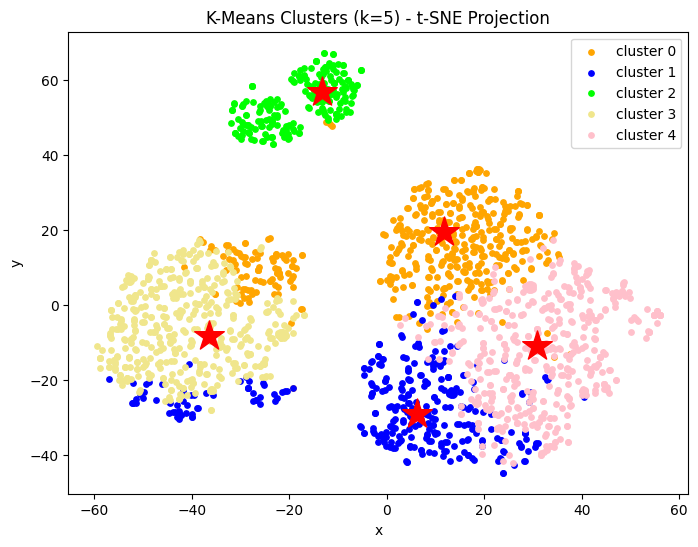

In [42]:
XYcoordinates_tsne = manifold.TSNE(n_components=2, random_state=RANDOM_STATE).fit_transform(data_and_centers)

print("t-SNE transformation complete")

plt.figure(figsize=(8, 6))

clustering_scatterplot(
    points=XYcoordinates_tsne[:-chosen_k, :],
    labels=kmeans_labels,
    centers=XYcoordinates_tsne[-chosen_k:, :],
    title=f"K-Means Clusters (k={chosen_k}) - t-SNE Projection"
)


plt.show()

In [43]:
cluster_df_analysis = df_clean.copy()
cluster_df_analysis["cluster"] = pd.Series(kmeans_labels, index=cluster_df_analysis.index)

display(cluster_df_analysis.head())

display(cluster_df_analysis.tail())

print("\nMean attribute values of eachh cluster:")

display(cluster_df_analysis.groupby("cluster").mean(numeric_only=True).round(3))

print("\nMost common genre per cluster:")

display(cluster_df_analysis.groupby("cluster")["track_genre"].agg(
    lambda x: x.value_counts().index[0]))

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,energy_acoustic_ratio,cluster
0,44.0,203337,0,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b,0.876948,4
1,83.0,208786,0,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop,1.882929,3
2,49.0,262373,0,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop,1.178655,3
3,0.0,191733,0,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop,2.808360,1
4,41.0,283706,0,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop,1.316891,3


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,energy_acoustic_ratio,cluster
1995,25.0,266133,0,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop,1.935720,4
1996,52.0,223236,0,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop,1.520358,4
1997,0.0,162009,0,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop,2.481626,1
1998,58.0,120000,0,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop,1.309333,3
1999,25.0,244026,0,0.746,0.570,7,-10.599,1,0.0389,0.6660,0.000005,0.3200,0.657,109.929,4,synth-pop,0.617654,4



Mean attribute values of eachh cluster:


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,energy_acoustic_ratio
cluster,,,,,,,,,,,,,,,,
0,42.545,226123.735,0.006,0.535,0.421,5.326,-9.813,0.800,0.054,0.625,0.037,0.167,0.340,112.517,3.796,0.591
1,37.110,226574.583,0.000,0.554,0.790,4.429,-6.218,0.815,0.063,0.040,0.053,0.210,0.513,136.168,3.967,3.940
2,39.367,199433.893,1.000,0.721,0.637,5.349,-6.291,0.544,0.137,0.171,0.010,0.180,0.480,121.123,3.944,2.436
3,42.039,217982.554,0.000,0.691,0.695,5.823,-6.393,0.000,0.086,0.217,0.026,0.188,0.615,117.067,3.963,1.918
4,37.031,211090.061,0.000,0.703,0.670,5.302,-7.224,1.000,0.080,0.289,0.021,0.169,0.712,118.531,3.925,1.547



Most common genre per cluster:


cluster
0    indie-pop
1    synth-pop
2      hip-hop
3          pop
4    synth-pop
Name: track_genre, dtype: str

### 3.3 DBSCAN Clustering

In [44]:
dbscan_results = []

for eps in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_cluster)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    noise_ratio = np.mean(labels == -1)
    sil = np.nan

    if n_clusters > 1:
        sil = silhouette_score(X_cluster, labels)
        
    dbscan_results.append({
        "eps": eps,
        "min_samples": 10,
        "n_clusters": n_clusters,
        "noise_ratio": round(noise_ratio, 3),
        "silhouette": sil
    })

display(pd.DataFrame(dbscan_results))

,eps,min_samples,n_clusters,noise_ratio,silhouette
0,1.5,10,18,0.807,-0.238201
1,2.0,10,4,0.131,0.094504
2,2.5,10,2,0.011,0.207196
3,3.0,10,2,0.000,0.220415
4,3.5,10,1,0.000,NaN
5,4.0,10,1,0.000,NaN


Clusters: 1
Noise ratio: 0.0


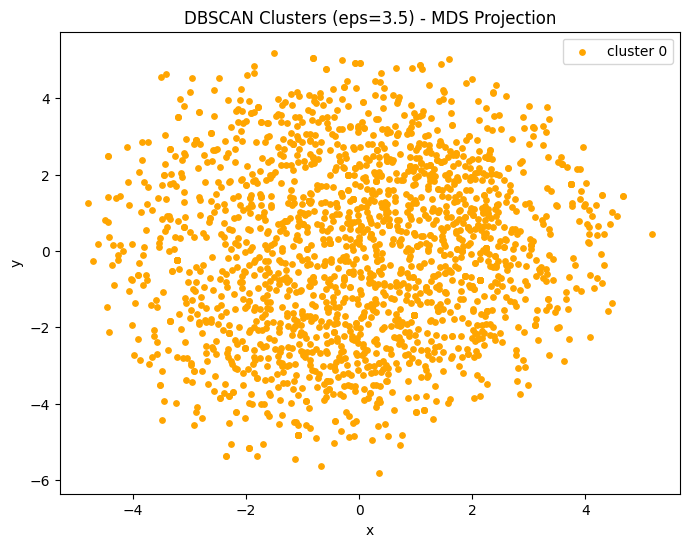


DBSCAN cluster vs genre cross-tabulation:


track_genre,hip-hop,indie-pop,pop,r-n-b,synth-pop
row_0,,,,,
0,0.15,0.25,0.25,0.15,0.2


In [45]:
chosen_eps = 3.5
db_final = DBSCAN(eps=chosen_eps, min_samples=10)
db_labels = db_final.fit_predict(X_cluster)

print("Clusters:", len(set(db_labels)) - (1 if -1 in db_labels else 0))
print("Noise ratio:", round(np.mean(db_labels == -1), 3))

plt.figure(figsize=(8, 6))
clustering_scatterplot(
    points=XYcoordinates[:-chosen_k, :],
    labels=db_labels,
    centers=None,
    title=f"DBSCAN Clusters (eps={chosen_eps}) - MDS Projection"
)

plt.show()

print("\nDBSCAN cluster vs genre cross-tabulation:")

display(pd.crosstab(db_labels, df_clean["track_genre"], normalize="index").round(2))

### 3.4 Clustering Conclusion
The elbow plot shows that inertia levels flattening after k=5, and the silhouette score peaks at k=3 but the ARI score against genre labels is highest at k=5. So we chose k=5. We also considered k=3, but it produced a lower ARI score against genre labels, meaining it combined genres that should be treated as differet.

The cluster mean table shows that there is a clear structure. The clusters are clearly different in terms of danceability, energy, acousticness, and speechiness, which broadly reflects the five genres even though genre labels were not used. 

The MDS and t-SNE projections show partial separation, but there is some overlap, particularly between hip-hop and R&B, which have similar audio characteristics.

DBSCAN found 1 cluster with a noise ratio of 0.0 at eps=3.5. It didn't align as well with genreas as K-Means did, and at lower eps values it labelled a large number of tracks as noise, and at eps=3.5 it collapsed everything into a single cluster. Therefore, K-Means was chosen as the final clustering solution.

## 4. Classification. Predicting Popularity Category

### 4.1 EDA for Classification

In [46]:
class_df = df_clean.copy()
median_popularity = class_df["popularity"].median()
class_df["popularity_binary"] = (class_df["popularity"] > median_popularity).astype(int)

print("Median popularity:", median_popularity)
print("popularity_binary = 0 if popularity <=", median_popularity)
print("popularity_binary = 1 if popularity >", median_popularity)

print("\nClass distribution:")
display(class_df["popularity_binary"].value_counts())
display(class_df["popularity_binary"].value_counts(normalize=True).rename("proportion").round(3))

Median popularity: 45.0
popularity_binary = 0 if popularity <= 45.0
popularity_binary = 1 if popularity > 45.0

Class distribution:


popularity_binary
0    994
1    966
Name: count, dtype: int64

popularity_binary
0    0.507
1    0.493
Name: proportion, dtype: float64

Missing values in predictors:


duration_ms              0
explicit                 0
danceability             0
energy                   0
key                      0
loudness                 0
mode                     0
speechiness              0
acousticness             0
instrumentalness         0
liveness                 0
valence                  0
tempo                    0
time_signature           0
energy_acoustic_ratio    0
dtype: int64

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence
count,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000
mean,0.635897,0.632489,0.078251,0.298259,0.030313,0.181199,0.539731
std,0.138298,0.189087,0.076115,0.280367,0.120463,0.150613,0.236181
min,0.185000,0.090900,0.022100,0.000007,0.000000,0.009860,0.035900
25%,0.548000,0.507750,0.034400,0.052475,0.000000,0.093800,0.353000
50%,0.646000,0.644000,0.047400,0.195500,0.000007,0.121500,0.534500
75%,0.738000,0.780000,0.083925,0.491250,0.000647,0.222000,0.729000
max,0.953000,0.996000,0.515000,0.990000,0.962000,0.986000,0.990000


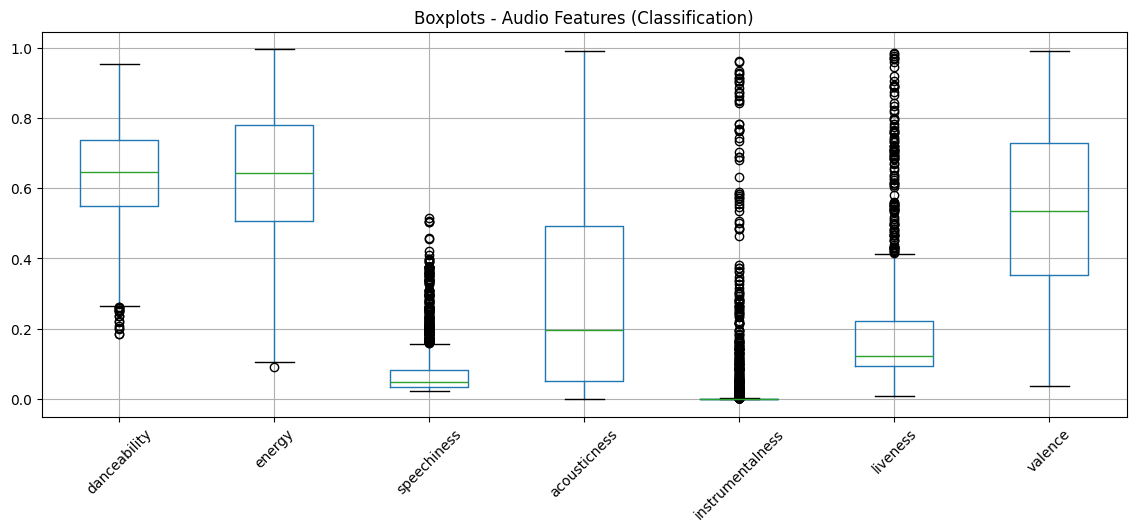

In [47]:
X_class = class_df.drop(columns=["popularity", "popularity_binary", "track_genre"])
y_class = class_df["popularity_binary"]
print("Missing values in predictors:")
display(X_class.isna().sum())

audio_cols = ["danceability","energy","speechiness","acousticness",
              "instrumentalness","liveness","valence"]
display(X_class[audio_cols].describe())
X_class[audio_cols].boxplot(figsize=(14, 5))
plt.title("Boxplots - Audio Features (Classification)")
plt.xticks(rotation=45)
plt.show() 

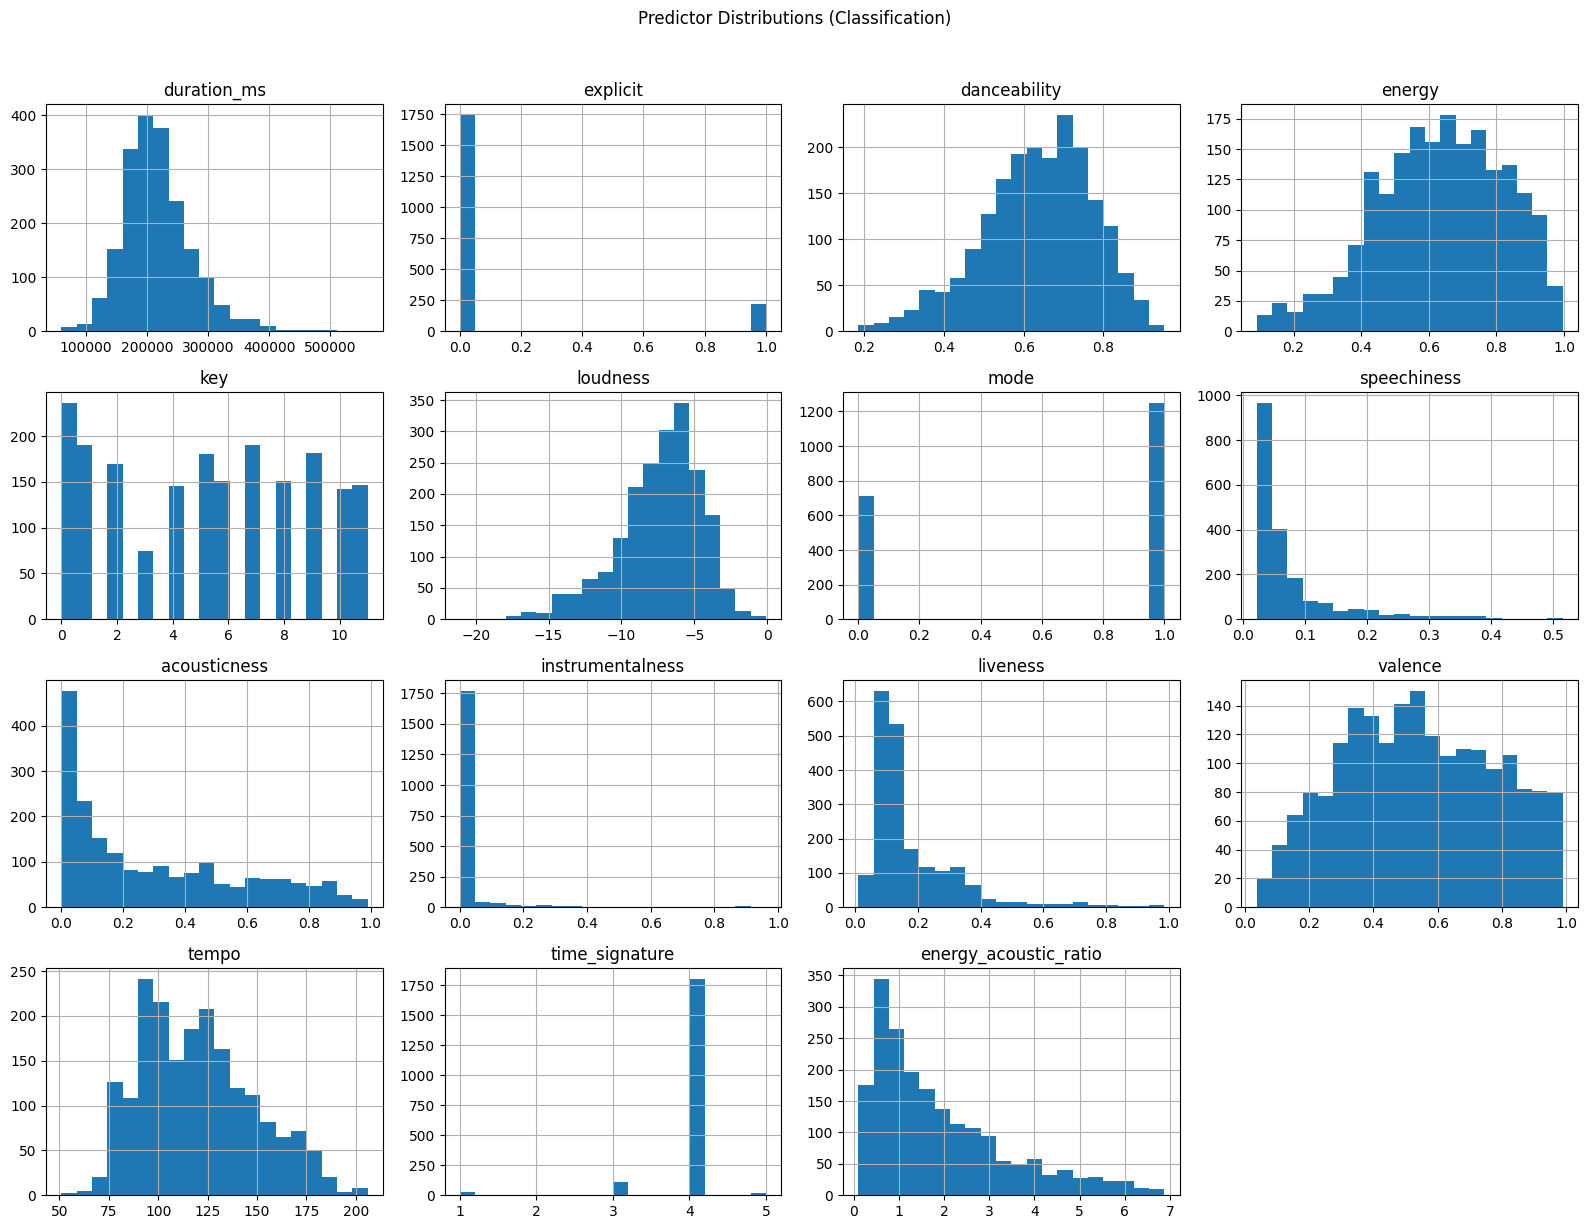

In [48]:
X_class.select_dtypes(include=np.number).hist(bins=20, figsize=(16, 12))
plt.suptitle("Predictor Distributions (Classification)", y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Data Preparation for Classification

In [49]:
columns_log_robust = ["speechiness", "instrumentalness", "liveness",
                      "duration_ms", "energy_acoustic_ratio"]

columns_robust_only = ["loudness"]

columns_ohe = ["key", "time_signature"]

columns_standard = [c for c in X_class.select_dtypes(include=np.number).columns
                    if c not in columns_log_robust + columns_robust_only + columns_ohe]

print("Log+Robust cols:", columns_log_robust)
print("Robust-only cols:", columns_robust_only)
print("OHE cols:", columns_ohe)
print("Standard cols:", columns_standard)

Log+Robust cols: ['speechiness', 'instrumentalness', 'liveness', 'duration_ms', 'energy_acoustic_ratio']
Robust-only cols: ['loudness']
OHE cols: ['key', 'time_signature']
Standard cols: ['explicit', 'danceability', 'energy', 'mode', 'acousticness', 'valence', 'tempo']


In [50]:
log_robust_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scaler", RobustScaler())
])
robust_only_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

standard_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

class_preprocess = ColumnTransformer(
    transformers=[
        ("log_robust", log_robust_pipeline,  columns_log_robust),
        ("robust_only", robust_only_pipeline, columns_robust_only),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), columns_ohe),
        ("standard", standard_pipeline, columns_standard)
    ]
)

set_config(display="diagram")
class_preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_robust', ...), ('robust_only', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, shuffle=True,
    stratify=y_class, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} examples")
print(f"Test set: {X_test.shape[0]} examples")

Training set: 1568 examples
Test set: 392 examples


### 4.3 Model Training with Cross-Validation

In [52]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "Accuracy": "accuracy",
    "F1-score": "f1",
    "Precision": "precision",
    "Recall": "recall",
    "ROC_AUC": "roc_auc",
    "AP": "average_precision"
}

In [53]:
pipe_lr = Pipeline(steps=[
    ("preprocess", class_preprocess),
    ("lr", LogisticRegression(max_iter=1000))
])

set_config(display="diagram")
pipe_lr

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_robust', ...), ('robust_only', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [54]:
param_grid_lr = {
    "lr__C": [0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l1", "l2"],
    "lr__solver": ["liblinear"]
}

lr_search = GridSearchCV(
    pipe_lr, param_grid_lr,
    n_jobs=-1, cv=cv, scoring=scoring,
    refit="F1-score", return_train_score=False
)

lr_search.fit(X_train, y_train)
print(f"Best CV F1 = {lr_search.best_score_:.3f}")
print("Best parameters:", lr_search.best_params_)

LR_best_model  = lr_search.best_estimator_
LR_best_cv_f1  = lr_search.best_score_

Best CV F1 = 0.581
Best parameters: {'lr__C': 0.1, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}


In [55]:
pipe_rf = Pipeline(steps=[
    ("preprocess", class_preprocess),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE))
])

set_config(display="diagram")
pipe_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_robust', ...), ('robust_only', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [56]:
param_grid_rf = {
    "rf__n_estimators": [50, 100, 200],
    "rf__max_depth": [4, 8, 12, None]
}

rf_search = GridSearchCV(
    pipe_rf, param_grid_rf,
    n_jobs=-1, cv=cv, scoring=scoring,
    refit="F1-score", return_train_score=False
)
rf_search.fit(X_train, y_train)
print(f"Best CV F1 = {rf_search.best_score_:.3f}")
print("Best parameters:", rf_search.best_params_)
RF_best_model  = rf_search.best_estimator_
RF_best_cv_f1  = rf_search.best_score_

Best CV F1 = 0.667
Best parameters: {'rf__max_depth': 12, 'rf__n_estimators': 200}


### 4.4 Cross-Validated Model Comparison (Training Set Only)

In [57]:
class_models = {
    "Logistic Regression (best by F1)": LR_best_model,
    "Random Forest (best by F1)": RF_best_model
}

cv_results_class = {}
for name, model in class_models.items():
    res = cross_validate(model, X_train, y_train,
                         cv=cv, scoring=scoring,
                         return_train_score=False, n_jobs=-1)
    cv_results_class[name] = {m: res[f"test_{m}"] for m in scoring.keys()}

for name, metrics_dict in cv_results_class.items():
    print("\n" + name)
    for m, vals in metrics_dict.items():
        print(f"  {m:9s}: mean={np.mean(vals):.3f}, std={np.std(vals):.3f}")


Logistic Regression (best by F1)
  Accuracy : mean=0.579, std=0.034
  F1-score : mean=0.582, std=0.042
  Precision: mean=0.571, std=0.035
  Recall   : mean=0.598, std=0.067
  ROC_AUC  : mean=0.599, std=0.028
  AP       : mean=0.589, std=0.044

Random Forest (best by F1)
  Accuracy : mean=0.663, std=0.026
  F1-score : mean=0.667, std=0.024
  Precision: mean=0.651, std=0.029
  Recall   : mean=0.686, std=0.039
  ROC_AUC  : mean=0.730, std=0.025
  AP       : mean=0.697, std=0.034


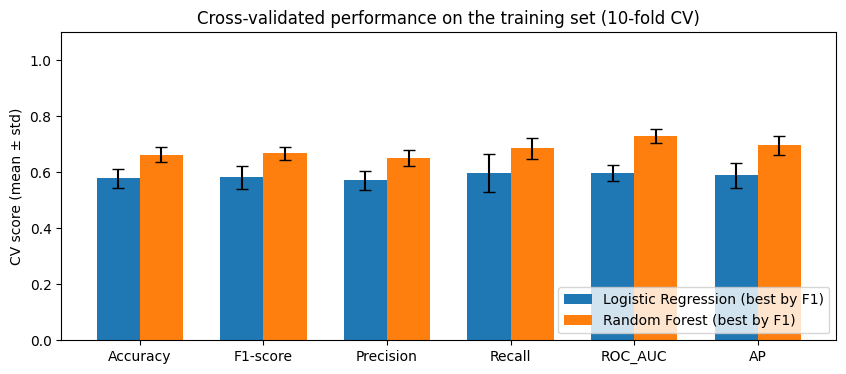

In [58]:
metric_names = list(scoring.keys())
labels = list(cv_results_class.keys())
means = {lab: [np.mean(cv_results_class[lab][m]) for m in metric_names] for lab in labels}
stds  = {lab: [np.std(cv_results_class[lab][m])  for m in metric_names] for lab in labels}

x = np.arange(len(metric_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, means[labels[0]], width, yerr=stds[labels[0]], capsize=4, label=labels[0])
ax.bar(x + width/2, means[labels[1]], width, yerr=stds[labels[1]], capsize=4, label=labels[1])
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel("CV score (mean ± std)")
ax.set_title("Cross-validated performance on the training set (10-fold CV)")
ax.legend(loc="lower right")
plt.show()

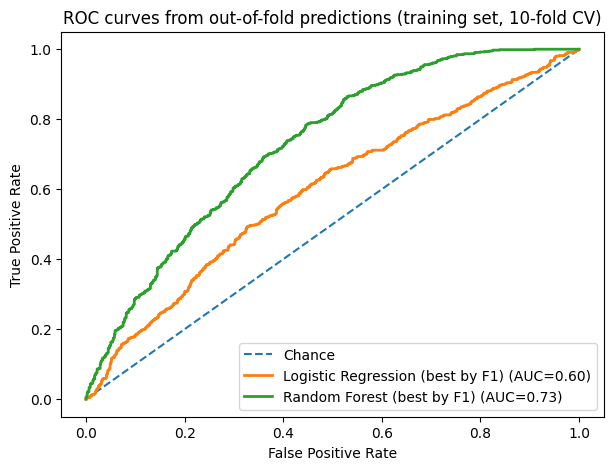

In [59]:
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

for name, model in class_models.items():
    oof_proba = cross_val_predict(model, X_train, y_train,
                                  cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    fpr, tpr, _ = roc_curve(y_train, oof_proba)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves from out-of-fold predictions (training set, 10-fold CV)")
plt.legend(loc="lower right")
plt.show()

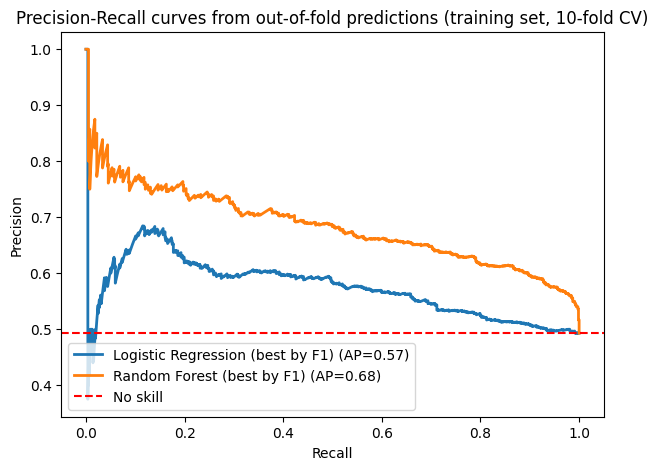

In [60]:
plt.figure(figsize=(7, 5))
for name, model in class_models.items():
    oof_proba = cross_val_predict(model, X_train, y_train,
                                  cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    prec, rec, _ = precision_recall_curve(y_train, oof_proba)
    ap = average_precision_score(y_train, oof_proba)
    plt.plot(rec, prec, lw=2, label=f"{name} (AP={ap:.2f})")

plt.axhline(y=y_train.mean(), color="red", linestyle="--", label="No skill")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves from out-of-fold predictions (training set, 10-fold CV)")
plt.legend(loc="lower left")
plt.show()

In [61]:
if LR_best_cv_f1 >= RF_best_cv_f1:
    best_class_name  = "Logistic Regression"
    best_class_model = LR_best_model
    best_class_cv_f1 = LR_best_cv_f1
else:
    best_class_name  = "Random Forest"
    best_class_model = RF_best_model
    best_class_cv_f1 = RF_best_cv_f1

print(f"Chosen model: {best_class_name} (mean CV F1 = {best_class_cv_f1:.3f})")

Chosen model: Random Forest (mean CV F1 = 0.667)


### 4.5 Final Evaluation on the Test Set

In [62]:
def evaluate_model(X_eval, y_eval, model):
    probabilities = model.predict_proba(X_eval)[:, 1]
    predicted = model.predict(X_eval)
    results = {
        "confusion_matrix": confusion_matrix(y_eval, predicted),
        "accuracy": accuracy_score(y_eval, predicted),
        "precision": precision_score(y_eval, predicted, zero_division=0),
        "recall": recall_score(y_eval, predicted, zero_division=0),
        "f1": f1_score(y_eval, predicted, zero_division=0)
    }
    fpr, tpr, _ = roc_curve(y_eval, probabilities)
    results["fpr"] = fpr; 
    results["tpr"] = tpr
    results["auc"] = auc(fpr, tpr)
    prc_p, prc_r, _ = precision_recall_curve(y_eval, probabilities)
    results["prc_precision"] = prc_p; results["prc_recall"] = prc_r
    results["ap"] = average_precision_score(y_eval, probabilities)
    return results

test_results = evaluate_model(X_test, y_test, best_class_model)

In [63]:
cm_df = pd.DataFrame(
    test_results["confusion_matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)
print("Confusion Matrix (Test Set):")
display(cm_df)

Confusion Matrix (Test Set):


,Predicted 0,Predicted 1
Actual 0,138,61
Actual 1,61,132


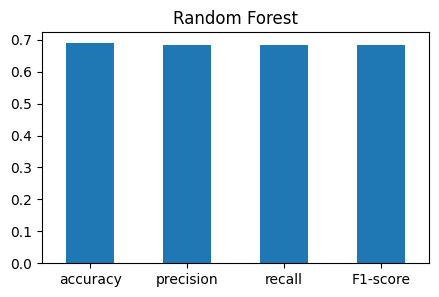

In [64]:
metrics_arr = np.array([test_results["accuracy"], test_results["precision"],
                        test_results["recall"],   test_results["f1"]])
df_metrics = pd.DataFrame({best_class_name: metrics_arr},
                           index=["accuracy","precision","recall","F1-score"])
df_metrics.plot.bar(rot=0, figsize=(5,3), legend=False, title=best_class_name)
plt.show() 

#Metrics are constient, indicating balanced performance aross both classes.

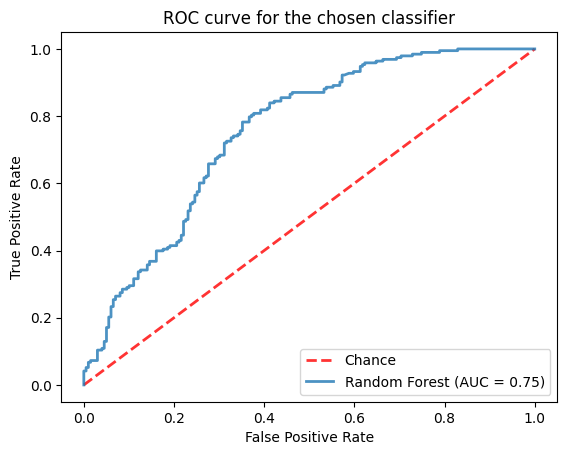

In [65]:
plt.plot([0,1],[0,1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)
plt.plot(test_results["fpr"], test_results["tpr"], lw=2,
         label=f"{best_class_name} (AUC = {test_results['auc']:.2f})", alpha=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve for the chosen classifier")
plt.legend(loc="lower right")
plt.show()

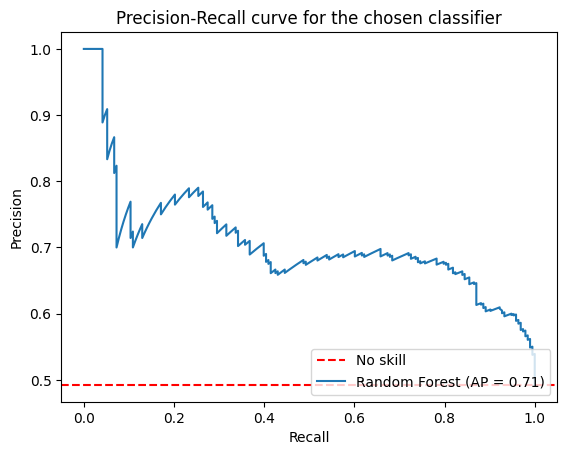

In [66]:
plt.axhline(y=y_test.mean(), color="red", linestyle="--", label="No skill")
plt.plot(test_results["prc_recall"], test_results["prc_precision"],
         label=f"{best_class_name} (AP = {test_results['ap']:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve for the chosen classifier")
plt.legend(loc="lower right")
plt.show()

,feature,importance
28,tempo,0.095115
27,valence,0.087229
0,speechiness,0.083011
3,duration_ms,0.082497
5,loudness,0.081834
2,liveness,0.081514
26,acousticness,0.081251
23,danceability,0.080985
4,energy_acoustic_ratio,0.079909
24,energy,0.077457


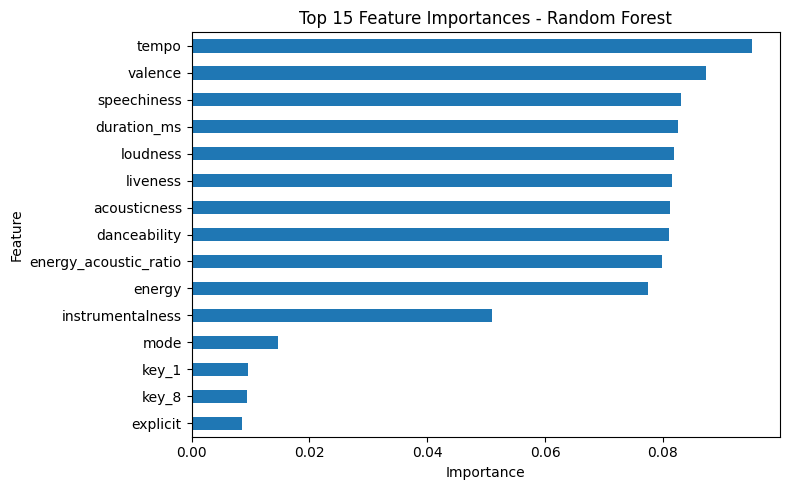

In [67]:
if best_class_name == "Random Forest":
    def get_preprocessor_feature_names(preprocessor):
        feature_names = []
        for name, transformer, cols in preprocessor.transformers_:
            if transformer == "drop":
                continue
            if transformer == "passthrough":
                feature_names.extend(cols if cols != "remainder" else list(preprocessor.feature_names_in_))
                continue

            if isinstance(transformer, Pipeline):
                final_estimator = transformer.steps[-1][1]
                if hasattr(final_estimator, "get_feature_names_out"):
                    feature_names.extend(final_estimator.get_feature_names_out(cols))
                elif hasattr(transformer, "get_feature_names_out"):
                    feature_names.extend(transformer.get_feature_names_out(cols))
                else:
                    feature_names.extend(cols)
            elif hasattr(transformer, "get_feature_names_out"):
                feature_names.extend(transformer.get_feature_names_out(cols))
            else:
                feature_names.extend(cols)

        return np.array(feature_names)

    feature_names = get_preprocessor_feature_names(best_class_model.named_steps["preprocess"])

    if best_class_name == "Random Forest":
        importances = best_class_model.named_steps["rf"].feature_importances_
    else:
        importances = np.abs(best_class_model.named_steps["lr"].coef_[0])
    #importances = best_class_model.named_steps["rf"].feature_importances_
else:
    feature_names = best_class_model.named_steps["preprocess"].get_feature_names_out()
    importances = np.abs(best_class_model.named_steps["lr"].coef_[0])

importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)
display(importance_df.head(15))

importance_df.head(15).sort_values("importance").plot(
    kind="barh", x="feature", y="importance", legend=False, figsize=(8,5))
plt.title(f"Top 15 Feature Importances - {best_class_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [68]:
pickle.dump(best_class_model, open("best_classification_model.sav", "wb"))
print("Model saved.")

Model saved.


## Section 4 Conclusions and Takeaways

We used F1 score because it balances recall and precision which are crucial for our classification.

Random Forest gave us the best performance and was generally better than Logistic Regression.This would indicate that non-linear realtionships between audio features and popularity are important and can't effectively be captured by a linear model.

ROC and Precision-Recall curves show that there is some reasonable discriminative ability. While it's not perfect, they reflect the complexity of predicting popularity based only on audio features.

Variables like energy, danceability, and acousticness were the most influencial predictors by our observation. This tells us that more energetic and engaging tracks tend to be more popular.

Overall, the classification performance was moderate. We found that audio features provided useful signals, but they don't fully explain popularity.

## 5. Regression. Predicting Popularity Score

### 5.1 EDA for Regression

In [88]:
reg_df = df_clean.copy()

print("Genre distribution:")
display(reg_df["track_genre"].value_counts())

print("\nTracks with popularity == 0:", (reg_df["popularity"] == 0).sum())

display(reg_df[reg_df["popularity"] == 0].head(3))

Genre distribution:


track_genre
indie-pop    494
pop          488
synth-pop    393
r-n-b        293
hip-hop      292
Name: count, dtype: int64


Tracks with popularity == 0: 422


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,energy_acoustic_ratio
3,0.0,191733,0,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.0,0.2640,0.716,90.959,4,indie-pop,2.808360
6,0.0,152000,0,0.712,0.251,6,-12.412,1,0.0473,0.8070,0.0,0.1080,0.627,79.956,5,indie-pop,0.270518
27,0.0,156265,0,0.637,0.705,10,-7.546,0,0.0502,0.1210,0.0,0.0857,0.553,158.013,4,indie-pop,1.913784


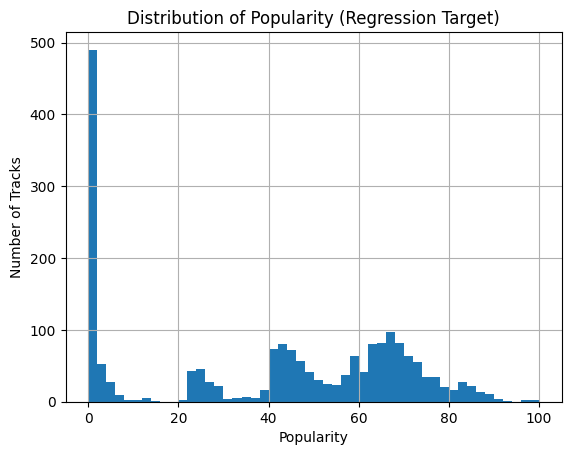

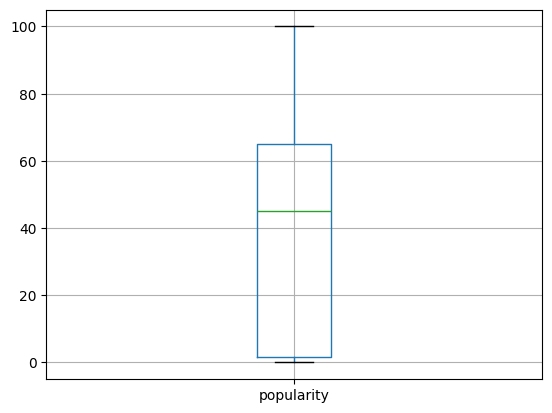

Basic statistics of the target variable:


count    1960.000000
mean       39.805102
std        29.245904
min         0.000000
25%         1.750000
50%        45.000000
75%        65.000000
max       100.000000
Name: popularity, dtype: float64

In [89]:
reg_df["popularity"].hist(bins=50)
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")
plt.title("Distribution of Popularity (Regression Target)")
plt.show()
reg_df.boxplot(column=["popularity"])
plt.show()
print("Basic statistics of the target variable:")
display(reg_df["popularity"].describe())

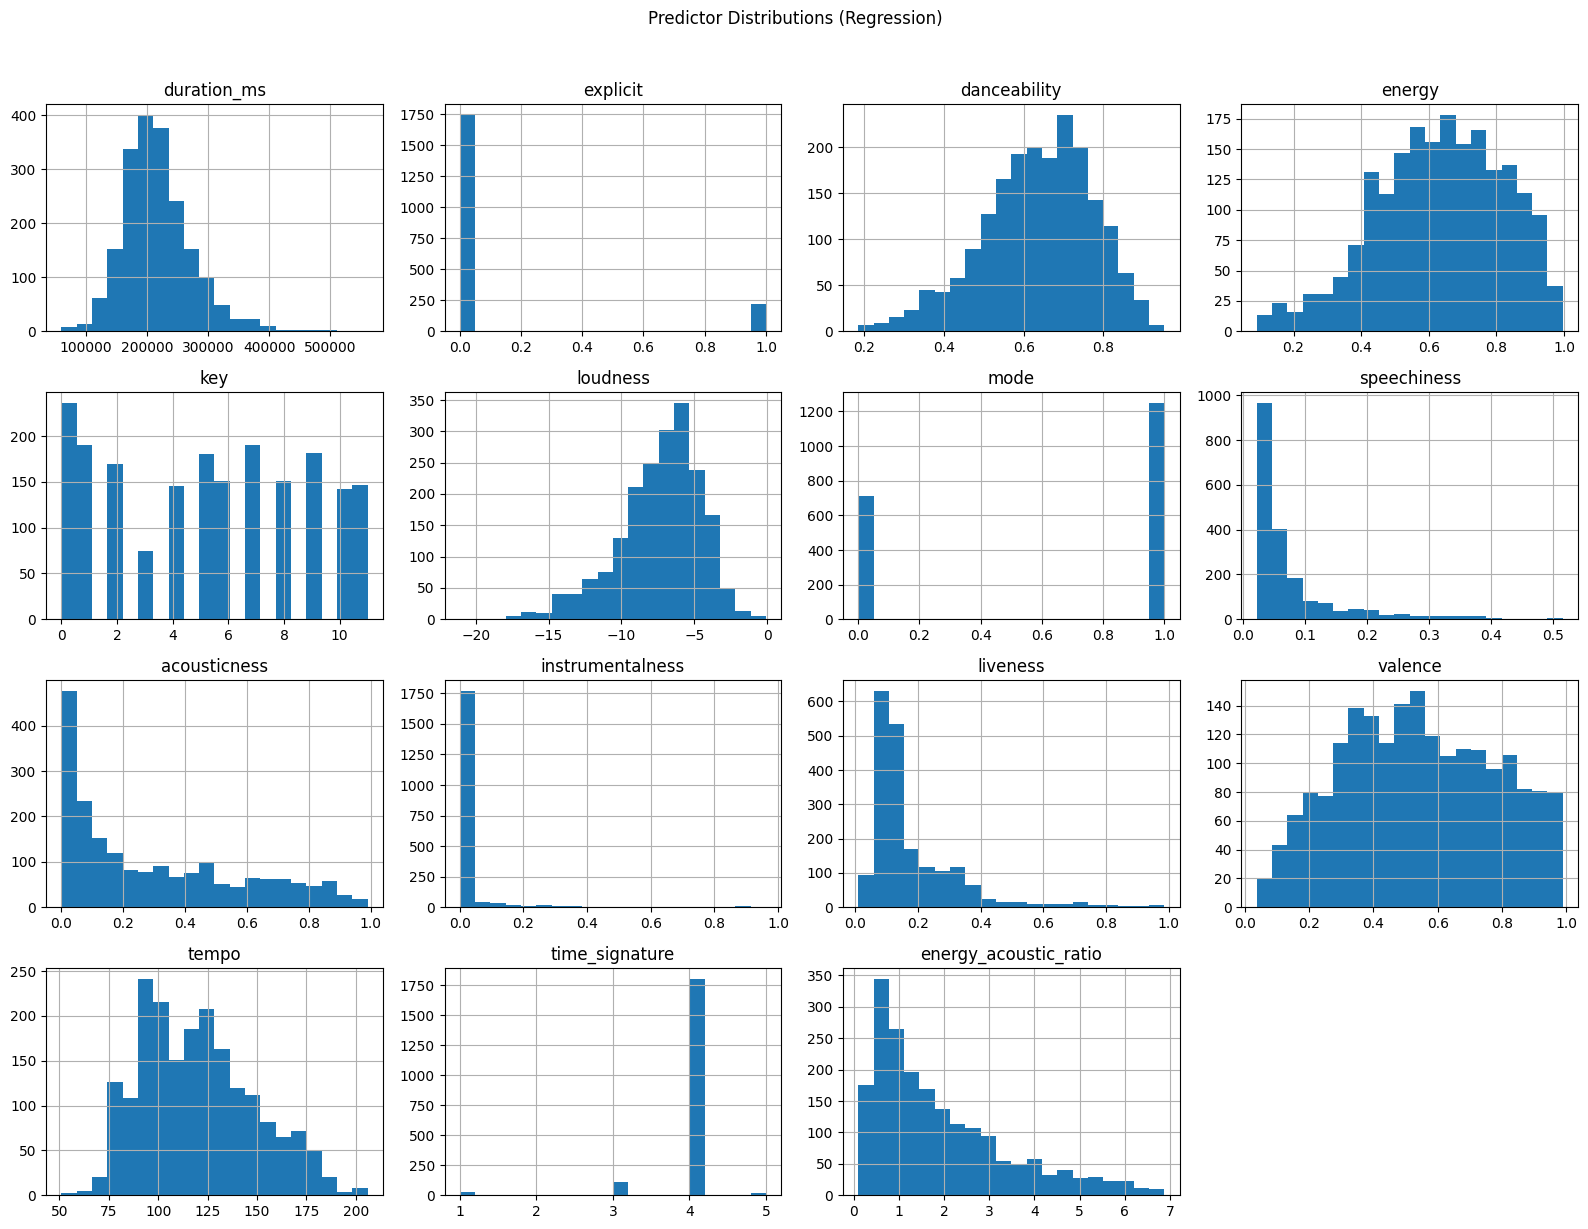

In [90]:
X_reg = reg_df.drop(columns=["popularity", "track_genre"])
y_reg = reg_df["popularity"]

X_reg.select_dtypes(include=np.number).hist(bins=20, figsize=(16, 12))
plt.suptitle("Predictor Distributions (Regression)", y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Data Preparation for Regression

In [91]:
reg_log_robust = ["speechiness","instrumentalness","liveness","duration_ms","energy_acoustic_ratio"]
reg_robust_only = ["loudness"]
reg_ohe = ["key","time_signature"]
reg_standard = [c for c in X_reg.select_dtypes(include=np.number).columns
                   if c not in reg_log_robust + reg_robust_only + reg_ohe]

reg_preprocess = ColumnTransformer(
    transformers=[
        ("log_robust", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("log_transform", FunctionTransformer(np.log1p)),
            ("scaler", RobustScaler())
        ]), reg_log_robust),
        ("robust_only", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), reg_robust_only),
        ("ohe", OneHotEncoder(drop="first", sparse_output=False,
                                      handle_unknown="ignore"), reg_ohe),
        ("standard", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), reg_standard)
    ]
).set_output(transform="pandas")

X_transformed = reg_preprocess.fit_transform(X_reg)
display(X_transformed.head())
display(X_transformed.tail())

,log_robust__speechiness,log_robust__instrumentalness,log_robust__liveness,log_robust__duration_ms,log_robust__energy_acoustic_ratio,robust_only__loudness,ohe__key_1,ohe__key_2,ohe__key_3,ohe__key_4,...,ohe__time_signature_3,ohe__time_signature_4,ohe__time_signature_5,standard__explicit,standard__danceability,standard__energy,standard__mode,standard__acousticness,standard__valence,standard__tempo
0,-0.418492,-0.010363,0.249932,-0.125232,-0.359036,0.953983,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,-0.353756,-0.201767,-0.420492,0.755323,0.338005,0.005376,0.840062
1,0.138373,0.025675,0.100010,-0.038716,0.217507,0.650076,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,-0.353756,1.006074,-0.103097,-1.323937,-0.675212,1.089567,-0.700520
2,-0.331233,0.006187,1.429284,0.708688,-0.158785,-0.589184,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,1.165191,-0.108387,-1.323937,-0.097250,1.606251,-0.065867
3,2.783162,-0.010363,1.079250,-0.317469,0.591505,0.947310,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,-0.389814,1.039527,0.755323,-0.877856,0.746522,-1.019915
4,-0.075669,0.013611,-0.595249,0.964428,-0.076140,0.068956,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,-0.353756,0.499794,0.425896,-1.323937,-0.136495,-0.176734,0.345766


,log_robust__speechiness,log_robust__instrumentalness,log_robust__liveness,log_robust__duration_ms,log_robust__energy_acoustic_ratio,robust_only__loudness,ohe__key_1,ohe__key_2,ohe__key_3,ohe__key_4,...,ohe__time_signature_3,ohe__time_signature_4,ohe__time_signature_5,standard__explicit,standard__danceability,standard__energy,standard__mode,standard__acousticness,standard__valence,standard__tempo
1995,0.293986,-0.010363,0.964309,0.755239,0.241884,1.080773,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,1.143493,1.515621,0.755323,-0.514667,1.792597,0.473812
1996,-0.308438,169.740478,-0.244643,0.180213,0.036943,-0.436257,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,0.224955,-0.018458,0.755323,-0.439746,-0.358845,-0.176693
1997,0.075402,-0.010363,-0.109269,-0.868563,0.471001,0.114556,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,-0.686350,0.637493,0.755323,-0.822557,0.136665,1.041723
1998,6.537799,-0.010363,0.781730,-1.850542,-0.080529,0.131517,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,1.570216,-0.642669,-1.323937,-0.393367,1.081096,-1.047551
1999,-0.174235,-0.003124,1.470390,0.471527,-0.558763,-1.021827,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.353756,0.796329,-0.330563,0.755323,1.311978,0.496650,-0.354610


In [92]:
#Train/test split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, shuffle=True, random_state=RANDOM_STATE
)
print(f"Training set: {Xr_train.shape[0]} examples")
print(f"Test set: {Xr_test.shape[0]} examples")

Training set: 1568 examples
Test set: 392 examples


### 5.3 Model Training with Cross-Validation

In [93]:
cv10 = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring_reg = {
    "neg_MSE": "neg_mean_squared_error",
    "neg_RMSE": "neg_root_mean_squared_error",
    "neg_MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

In [94]:
pipe_rfr = Pipeline(steps=[
    ("preprocess", reg_preprocess),
    ("reduce_dim", "passthrough"),
    ("ttr", TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
    ))
])

N_FEATURES_OPTIONS = [4, 8, 12]
MAX_DEPTH_OPTIONS = [4, 8, 12]

param_grid_rfr = [
    {
        "reduce_dim": [PCA(iterated_power=7)],
        "reduce_dim__n_components": N_FEATURES_OPTIONS,
        "ttr__regressor__max_depth": MAX_DEPTH_OPTIONS
    },
    {
        "reduce_dim": [RFE(LinearRegression())],
        "reduce_dim__n_features_to_select": N_FEATURES_OPTIONS,
        "ttr__regressor__max_depth": MAX_DEPTH_OPTIONS
    }
]
rfr_search = GridSearchCV(
    pipe_rfr, param_grid_rfr,
    scoring=scoring_reg, n_jobs=-1,
    cv=cv10, refit="R2", return_train_score=False
)
rfr_search.fit(Xr_train, yr_train)
print(f"Best CV R2 = {rfr_search.best_score_:.3f}")
print("Best parameters:", rfr_search.best_params_)
RF_reg_best_model  = rfr_search.best_estimator_
RF_reg_best_cv_r2  = rfr_search.best_score_

Best CV R2 = 0.243
Best parameters: {'reduce_dim': PCA(iterated_power=7), 'reduce_dim__n_components': 12, 'ttr__regressor__max_depth': 12}


In [95]:
pipe_lr_reg = Pipeline(steps=[
    ("preprocess", reg_preprocess),
    ("reduce_dim", "passthrough"),
    ("ttr", TransformedTargetRegressor(
        regressor=LinearRegression()
    ))
])

param_grid_lr_reg = [
    {
        "reduce_dim": [PCA(iterated_power=7)],
        "reduce_dim__n_components": N_FEATURES_OPTIONS,
        "ttr__regressor__fit_intercept": [True, False]
    },
    {
        "reduce_dim": [RFE(LinearRegression())],
        "reduce_dim__n_features_to_select": N_FEATURES_OPTIONS,
        "ttr__regressor__fit_intercept": [True, False]
    }
]

lr_reg_search = GridSearchCV(
    pipe_lr_reg, param_grid_lr_reg,
    scoring=scoring_reg, n_jobs=-1,
    cv=cv10, refit="R2", return_train_score=False
)
lr_reg_search.fit(Xr_train, yr_train)
print(f"Best CV R² = {lr_reg_search.best_score_:.3f}")
print("Best parameters:", lr_reg_search.best_params_)

LR_reg_best_model  = lr_reg_search.best_estimator_
LR_reg_best_cv_r2  = lr_reg_search.best_score_

Best CV R² = 0.002
Best parameters: {'reduce_dim': PCA(iterated_power=7), 'reduce_dim__n_components': 12, 'ttr__regressor__fit_intercept': True}


### 5.4 Cross-Validated Model Comparison (Training Set Only)

In [96]:
reg_models = {
    "Random Forest":      RF_reg_best_model,
    "Linear Regression":  LR_reg_best_model
}

cv_results_reg = {}
negative_metrics_reg = [k for k in scoring_reg if k.startswith("neg_")]
for name, model in reg_models.items():
    res = cross_validate(model, Xr_train, yr_train,
                         cv=cv10, scoring=scoring_reg,
                         return_train_score=False, n_jobs=-1)
    cv_results_reg[name] = {m: res[f"test_{m}"] for m in scoring_reg.keys()}

for name, metrics_dict in cv_results_reg.items():
    print("\n" + name)
    for m, vals in metrics_dict.items():
        sign = -1 if m in negative_metrics_reg else 1
        label = m.replace("neg_","")
        print(f"{label:5s}: mean={sign*np.mean(vals):.3f}, std={np.std(vals):.3f}")


Random Forest
MSE  : mean=646.272, std=67.367
RMSE : mean=25.388, std=1.306
MAE  : mean=20.372, std=1.045
R2   : mean=0.243, std=0.056

Linear Regression
MSE  : mean=851.491, std=53.985
RMSE : mean=29.165, std=0.930
MAE  : mean=25.612, std=1.003
R2   : mean=0.002, std=0.028


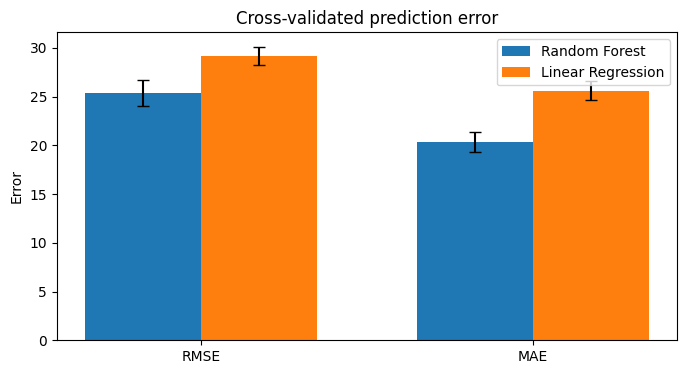

In [97]:
model_names_reg = list(reg_models.keys())
error_metrics = ["neg_RMSE", "neg_MAE"]
display_errors = ["RMSE", "MAE"]

x = np.arange(len(error_metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
for i, name in enumerate(model_names_reg):
    values = [-np.mean(cv_results_reg[name][m]) for m in error_metrics]
    stds = [ np.std(cv_results_reg[name][m]) for m in error_metrics]
    ax.bar(x + (i-0.5)*width, values, width, yerr=stds, capsize=4, label=name)
ax.set_xticks(x); ax.set_xticklabels(display_errors)
ax.set_ylabel("Error"); ax.set_title("Cross-validated prediction error")
ax.legend(); 
plt.show()

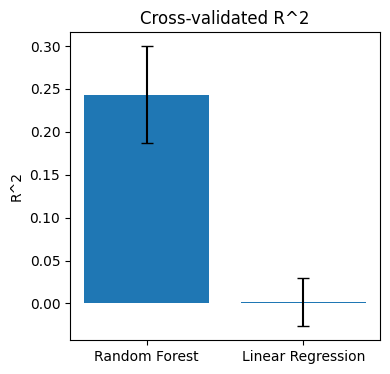

In [98]:
fig, ax = plt.subplots(figsize=(4, 4))
means_r2 = [np.mean(cv_results_reg[n]["R2"]) for n in model_names_reg]
stds_r2 = [np.std(cv_results_reg[n]["R2"])  for n in model_names_reg]
ax.bar(model_names_reg, means_r2, yerr=stds_r2, capsize=4)
ax.set_ylabel("R^2"); ax.set_title("Cross-validated R^2")
plt.show()

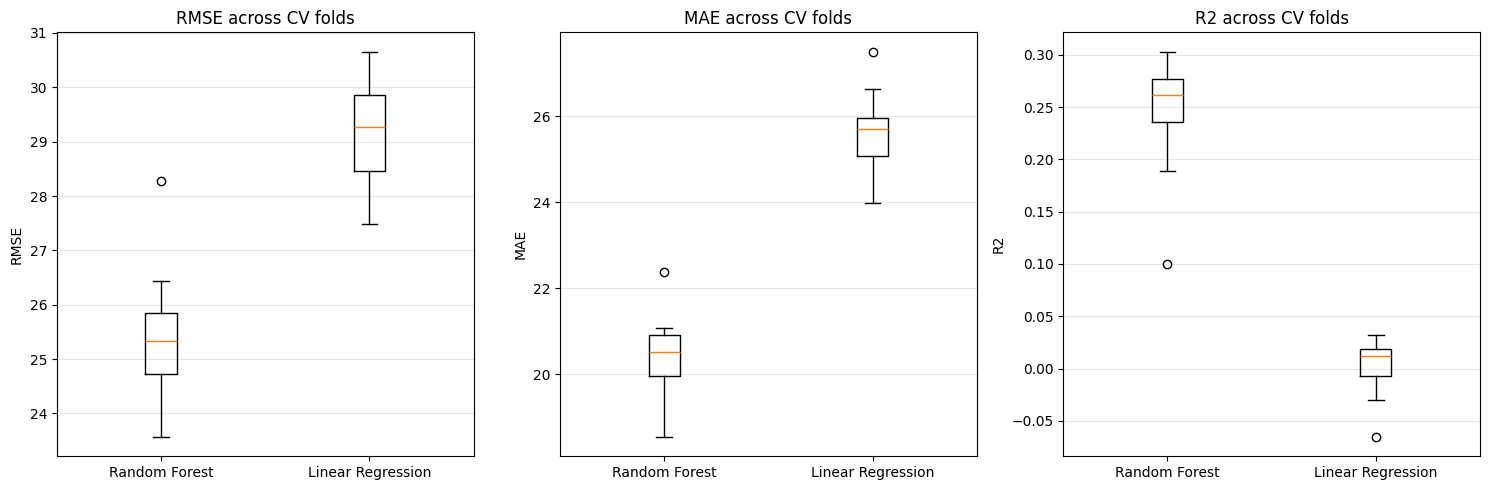

In [99]:
rmse_data = [-cv_results_reg[n]["neg_RMSE"] for n in model_names_reg]
mae_data = [-cv_results_reg[n]["neg_MAE"] for n in model_names_reg]
r2_data = [ cv_results_reg[n]["R2"] for n in model_names_reg]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].boxplot(rmse_data, tick_labels=model_names_reg)
axes[0].set_title("RMSE across CV folds"); axes[0].set_ylabel("RMSE"); 
axes[0].grid(axis="y", alpha=0.3)
axes[1].boxplot(mae_data, tick_labels=model_names_reg)
axes[1].set_title("MAE across CV folds"); axes[1].set_ylabel("MAE");  
axes[1].grid(axis="y", alpha=0.3)
axes[2].boxplot(r2_data, tick_labels=model_names_reg)
axes[2].set_title("R2 across CV folds"); axes[2].set_ylabel("R2");   
axes[2].grid(axis="y", alpha=0.3)
plt.tight_layout(); 
plt.show()

In [100]:
if RF_reg_best_cv_r2 >= LR_reg_best_cv_r2:
    best_reg_name  = "Random Forest"
    best_reg_model = RF_reg_best_model
    best_reg_cv_r2 = RF_reg_best_cv_r2
else:
    best_reg_name  = "Linear Regression"
    best_reg_model = LR_reg_best_model
    best_reg_cv_r2 = LR_reg_best_cv_r2

print(f"Chosen model: {best_reg_name} (mean CV R2 = {best_reg_cv_r2:.3f})")

Chosen model: Random Forest (mean CV R2 = 0.243)


### 5.5 Final Evaluation on the Test Set

In [101]:
yr_pred = best_reg_model.predict(Xr_test)

metrics_reg = {
    "MSE": mean_squared_error(yr_test, yr_pred),
    "RMSE": np.sqrt(mean_squared_error(yr_test, yr_pred)),
    "MAE": mean_absolute_error(yr_test, yr_pred),
    "R2": r2_score(yr_test, yr_pred)
}

print("\nTest set performance")
for m, val in metrics_reg.items():
    print(f"  {m:5s}: {val:.3f}")


Test set performance
  MSE  : 652.394
  RMSE : 25.542
  MAE  : 20.145
  R2   : 0.226


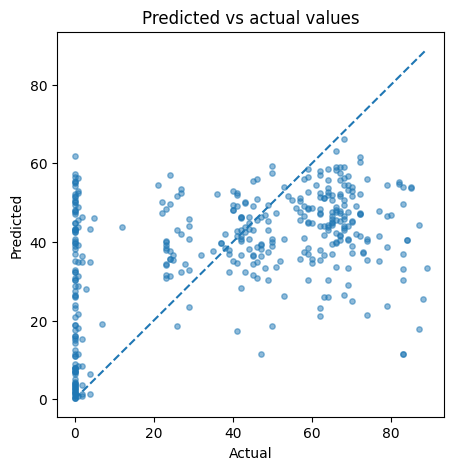

In [102]:
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, yr_pred, s=15, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs actual values")
min_val = min(yr_test.min(), yr_pred.min())
max_val = max(yr_test.max(), yr_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

In [103]:
pickle.dump(best_reg_model, open("best_regression_model.sav", "wb"))
print("Regression model saved.")

Regression model saved.


## Section 5 Conclusions and Takeaways

R2 was used as the main metric because it measures the proportion of variance in popularity.

Random Forest did better in general than Linear Regression, which indicates that non-linear relationships and feature interactions are important for prediciting popularity. However, the overall R^2 was moderate (RF: 0.243, Linear: 0.002 on cross-validation), meaning Random Forest explained around 24% of the popularity variance, while Linear Regression offered almost no predictive power, which says the relationship between audio features and popularity is non-linear.

The predicted vs actual scatter plot shows a large dispersion around the diagonal, indicating that the model struggles with predicting exact popularity values.

This confirmed to us that predicting the exact popularity was more difficult than binary classification because popularity is influenced by several external factors that wouldn't be represented in the dataset, like marketing and overall exposure.

Overall, Random Forest achieved a moderate R² of 0.226 on the test set, which is a reasonable result given that only audio features are available. Linear Regression struggled significantly, further confirming that non-linear relationships dominate.